In [1]:
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# STEP 1 — Load & Prepare Time Series Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
# ============================================================
# 1.1 — Load the dataset
# ============================================================
df = pd.read_csv('train_cleaned.csv')
print("✅ Dataset loaded successfully")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# ============================================================
# 1.2 — Check available columns
# ============================================================
print("📋 Columns available:")
print(list(df.columns))
print()

✅ Dataset loaded successfully
   Shape: 9792 rows × 19 columns

📋 Columns available:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Delivery Days']



In [4]:
# ============================================================
# 1.3 — Parse Order Date properly
# ============================================================
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
print("📅 Order Date parsed successfully")
print(f"   Date range: {df['Order Date'].min().date()} "
      f"to {df['Order Date'].max().date()}")
print(f"   Total days : {(df['Order Date'].max() - df['Order Date'].min()).days}\n")

📅 Order Date parsed successfully
   Date range: 2015-01-03 to 2018-12-30
   Total days : 1457



In [5]:
# ============================================================
# 1.4 — Aggregate daily sales to monthly
# (ARIMA needs evenly spaced time intervals)
# ============================================================
df.set_index('Order Date', inplace=True)

monthly_sales = df['Sales'].resample('MS').sum()
# MS = Month Start frequency — first day of each month

print("📆 Monthly Sales aggregation:")
print(f"   Total months : {len(monthly_sales)}")
print(f"   First month  : {monthly_sales.index[0].strftime('%B %Y')}")
print(f"   Last month   : {monthly_sales.index[-1].strftime('%B %Y')}")
print(f"   Min sales    : ${monthly_sales.min():,.2f}")
print(f"   Max sales    : ${monthly_sales.max():,.2f}")
print(f"   Mean sales   : ${monthly_sales.mean():,.2f}\n")

📆 Monthly Sales aggregation:
   Total months : 48
   First month  : January 2015
   Last month   : December 2018
   Min sales    : $4,519.89
   Max sales    : $117,393.77
   Mean sales   : $47,080.11



In [6]:
# ============================================================
# 1.5 — Check for missing months (gaps in time series)
# ============================================================
full_range = pd.date_range(
    start=monthly_sales.index[0],
    end=monthly_sales.index[-1],
    freq='MS'
)
missing_months = full_range.difference(monthly_sales.index)

if len(missing_months) == 0:
    print("✅ No missing months — time series is complete\n")
else:
    print(f"⚠️  {len(missing_months)} missing months found:")
    print(missing_months)
    # Fill missing months with interpolation
    monthly_sales = monthly_sales.reindex(full_range).interpolate()
    print("   Filled with interpolation\n")

✅ No missing months — time series is complete



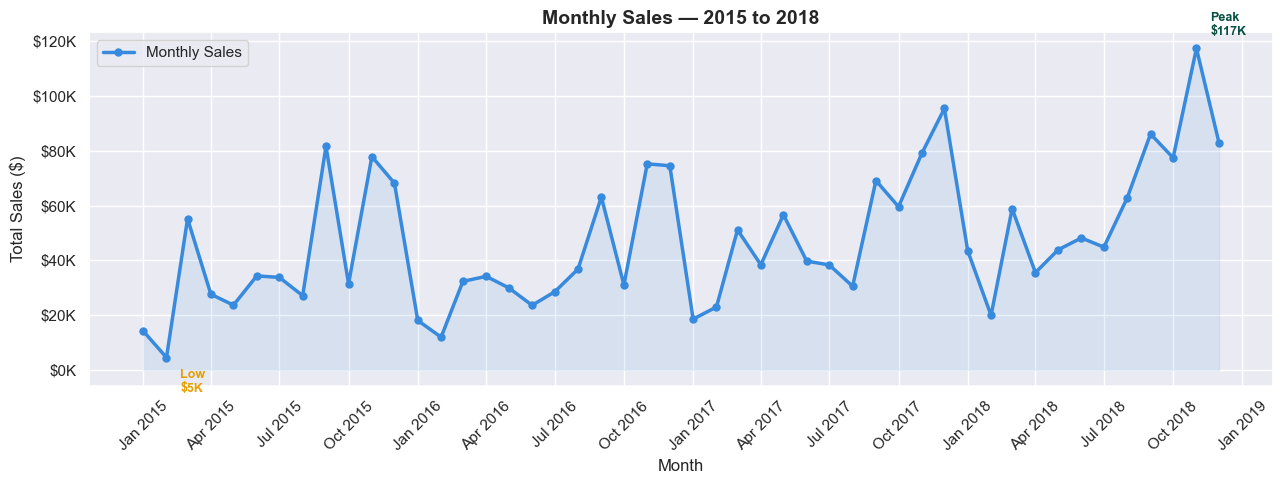

📸 Saved: monthly_sales_raw.png



In [7]:
# ============================================================
# 1.6 — Plot raw monthly sales
# ============================================================
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_sales.index, monthly_sales.values,
        color='#378ADD', linewidth=2.5, marker='o',
        markersize=5, label='Monthly Sales')
ax.fill_between(monthly_sales.index, monthly_sales.values,
                alpha=0.1, color='#378ADD')

# Annotate max and min points
max_idx = monthly_sales.idxmax()
min_idx = monthly_sales.idxmin()
ax.annotate(f'Peak\n${monthly_sales.max()/1000:.0f}K',
            xy=(max_idx, monthly_sales.max()),
            xytext=(10, 10), textcoords='offset points',
            fontsize=9, color='#085041', fontweight='bold')
ax.annotate(f'Low\n${monthly_sales.min()/1000:.0f}K',
            xy=(min_idx, monthly_sales.min()),
            xytext=(10, -25), textcoords='offset points',
            fontsize=9, color='#E5A000', fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Monthly Sales — 2015 to 2018',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('monthly_sales_raw.png', dpi=150)
plt.show()
print("📸 Saved: monthly_sales_raw.png\n")

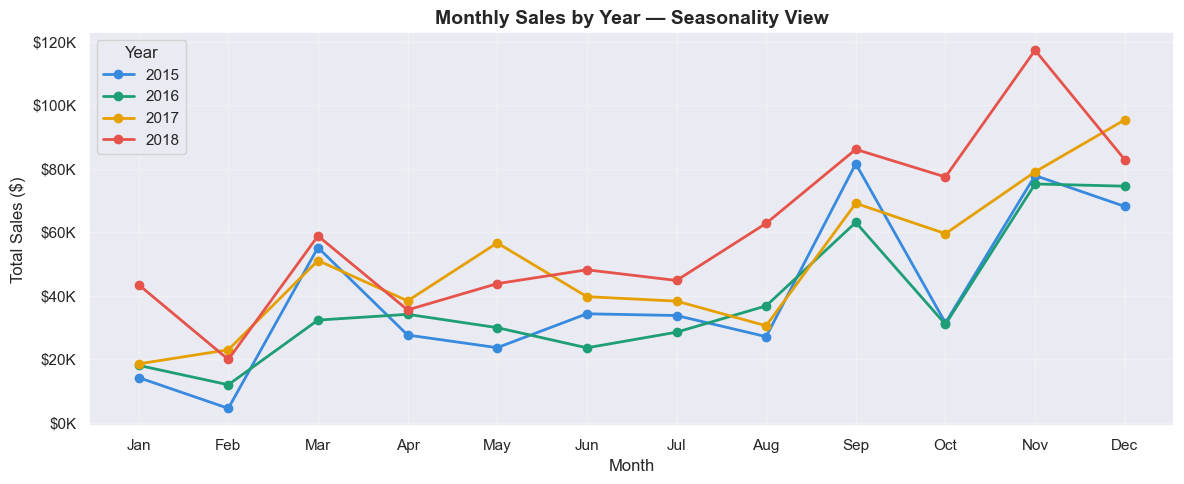

📸 Saved: sales_by_year.png



In [8]:
# ============================================================
# 1.7 — Monthly sales by year (overlay comparison)
# ============================================================
monthly_df = monthly_sales.reset_index()
monthly_df.columns = ['Date', 'Sales']
monthly_df['Year']  = monthly_df['Date'].dt.year
monthly_df['Month'] = monthly_df['Date'].dt.month

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#378ADD', '#1D9E75', '#E5A000', '#E5534B']
years  = sorted(monthly_df['Year'].unique())

for year, color in zip(years, colors):
    yearly = monthly_df[monthly_df['Year'] == year]
    ax.plot(yearly['Month'], yearly['Sales'],
            marker='o', label=str(year),
            color=color, linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly Sales by Year — Seasonality View',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(title='Year')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_by_year.png', dpi=150)
plt.show()
print("📸 Saved: sales_by_year.png\n")

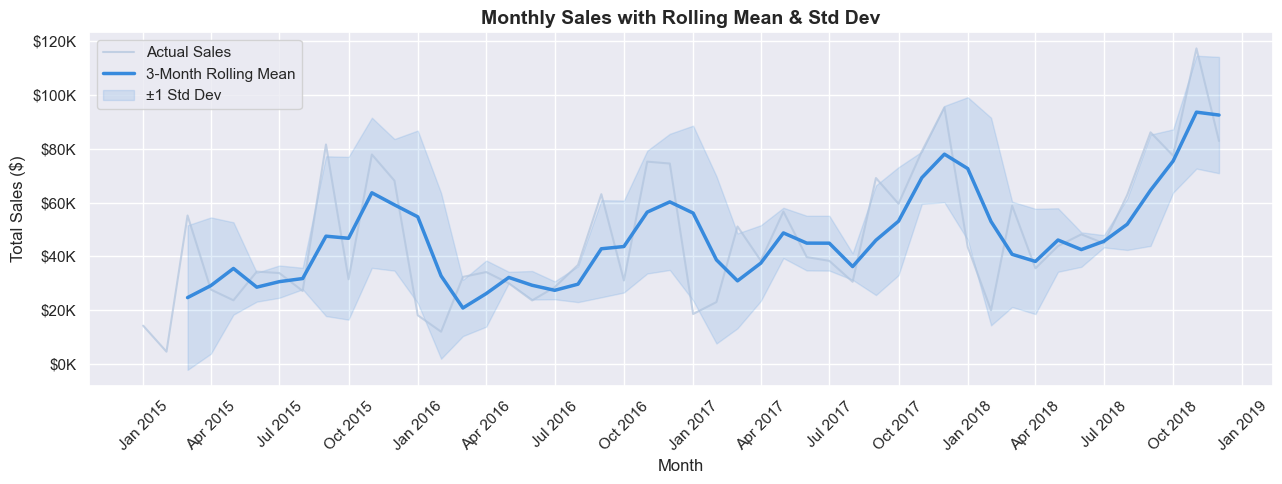

📸 Saved: rolling_statistics.png



In [9]:
# ============================================================
# 1.8 — Rolling statistics (trend smoothing)
# ============================================================
rolling_mean = monthly_sales.rolling(window=3).mean()
rolling_std  = monthly_sales.rolling(window=3).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_sales, color='#B0C4DE',
        linewidth=1.5, label='Actual Sales', alpha=0.7)
ax.plot(rolling_mean, color='#378ADD',
        linewidth=2.5, label='3-Month Rolling Mean')
ax.fill_between(monthly_sales.index,
                rolling_mean - rolling_std,
                rolling_mean + rolling_std,
                alpha=0.15, color='#378ADD',
                label='±1 Std Dev')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Monthly Sales with Rolling Mean & Std Dev',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('rolling_statistics.png', dpi=150)
plt.show()
print("📸 Saved: rolling_statistics.png\n")

In [10]:
# ============================================================
# 1.9 — Save monthly_sales for use in all future steps
# ============================================================
monthly_sales.to_csv('monthly_sales.csv')
print("💾 Saved: monthly_sales.csv\n")

# ============================================================
# 1.10 — Step Summary
# ============================================================
print("=" * 50)
print("✅ STEP 1 COMPLETE — Time Series Data Ready")
print("=" * 50)
print(f"  Date range    : {monthly_sales.index[0].strftime('%b %Y')} "
      f"→ {monthly_sales.index[-1].strftime('%b %Y')}")
print(f"  Total months  : {len(monthly_sales)}")
print(f"  Mean sales    : ${monthly_sales.mean():,.2f}")
print(f"  Max sales     : ${monthly_sales.max():,.2f}")
print(f"  Min sales     : ${monthly_sales.min():,.2f}")
print()
print("  Variables ready for Step 2:")
print("  ✔ monthly_sales (time series)")
print("  ✔ monthly_sales.csv (saved to disk)")
print()
print("  📸 Plots saved:")
print("     ✔ monthly_sales_raw.png")
print("     ✔ sales_by_year.png")
print("     ✔ rolling_statistics.png")

💾 Saved: monthly_sales.csv

✅ STEP 1 COMPLETE — Time Series Data Ready
  Date range    : Jan 2015 → Dec 2018
  Total months  : 48
  Mean sales    : $47,080.11
  Max sales     : $117,393.77
  Min sales     : $4,519.89

  Variables ready for Step 2:
  ✔ monthly_sales (time series)
  ✔ monthly_sales.csv (saved to disk)

  📸 Plots saved:
     ✔ monthly_sales_raw.png
     ✔ sales_by_year.png
     ✔ rolling_statistics.png


In [11]:
# ============================================================
# STEP 2 — Exploratory Analysis & Decomposition
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

In [12]:
# ============================================================
# 2.1 — Reload monthly sales (in case of kernel restart)
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'

print("✅ Monthly sales loaded")
print(f"   Shape : {monthly_sales.shape}")
print(f"   Period: {monthly_sales.index[0].strftime('%b %Y')} "
      f"→ {monthly_sales.index[-1].strftime('%b %Y')}\n")

✅ Monthly sales loaded
   Shape : (48,)
   Period: Jan 2015 → Dec 2018



🔍 Running Classical Decomposition (Additive)...



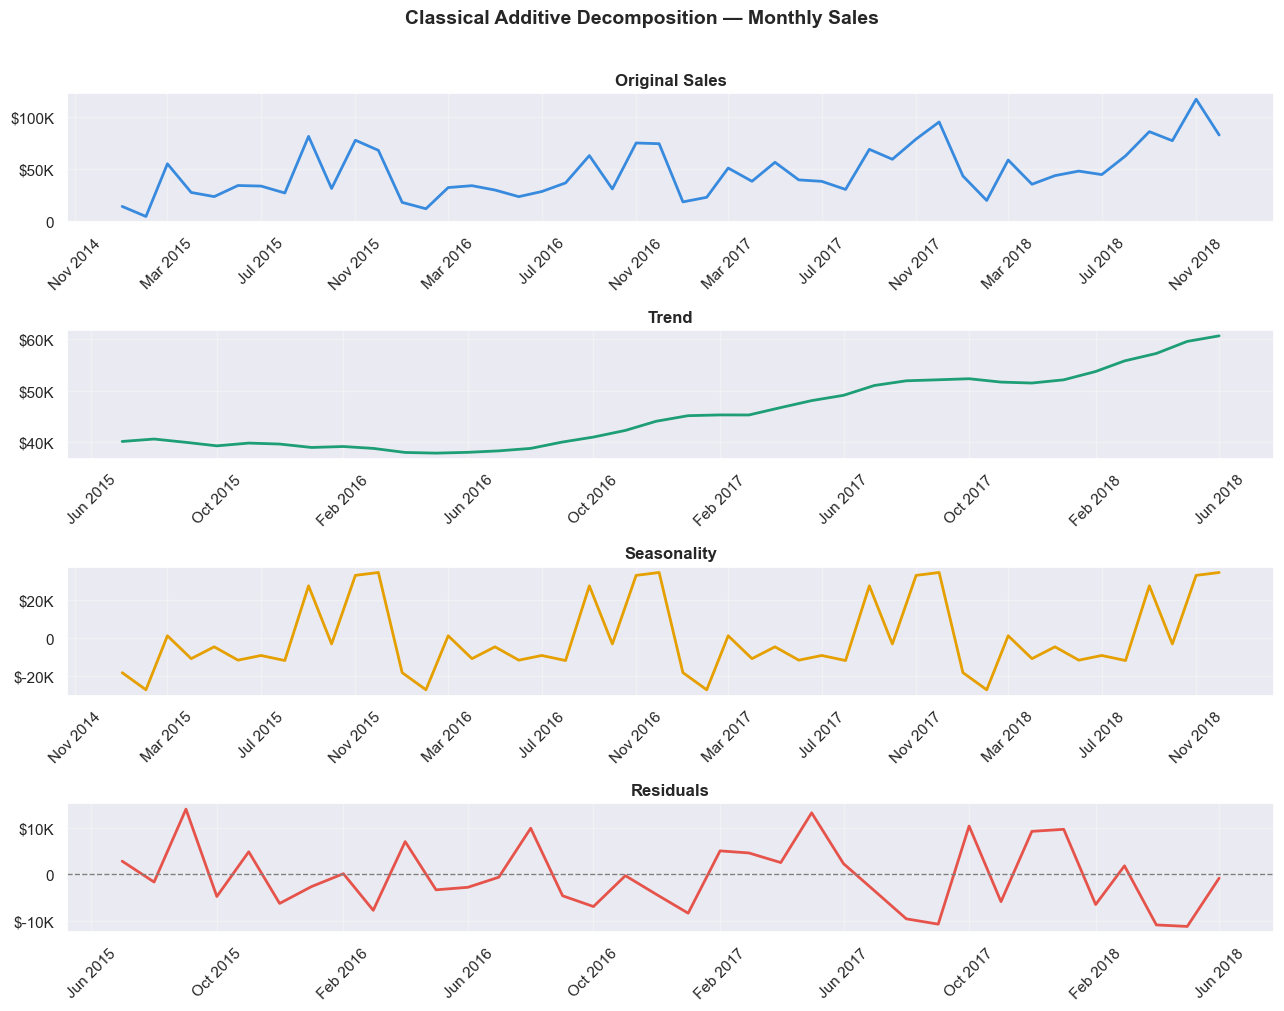

📸 Saved: classical_decomposition.png



In [13]:
# ============================================================
# 2.2 — Classical Decomposition (Additive)
# ============================================================
print("🔍 Running Classical Decomposition (Additive)...\n")

decomp_add = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))

components = [
    (monthly_sales,         'Original Sales',  '#378ADD'),
    (decomp_add.trend,      'Trend',           '#1D9E75'),
    (decomp_add.seasonal,   'Seasonality',     '#E5A000'),
    (decomp_add.resid,      'Residuals',       '#E5534B'),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'
                          if abs(x) > 100 else f'{x:.0f}'))
    ax.grid(True, alpha=0.3)
    if title == 'Residuals':
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.suptitle('Classical Additive Decomposition — Monthly Sales',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('classical_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("📸 Saved: classical_decomposition.png\n")

🔍 Running STL Decomposition...



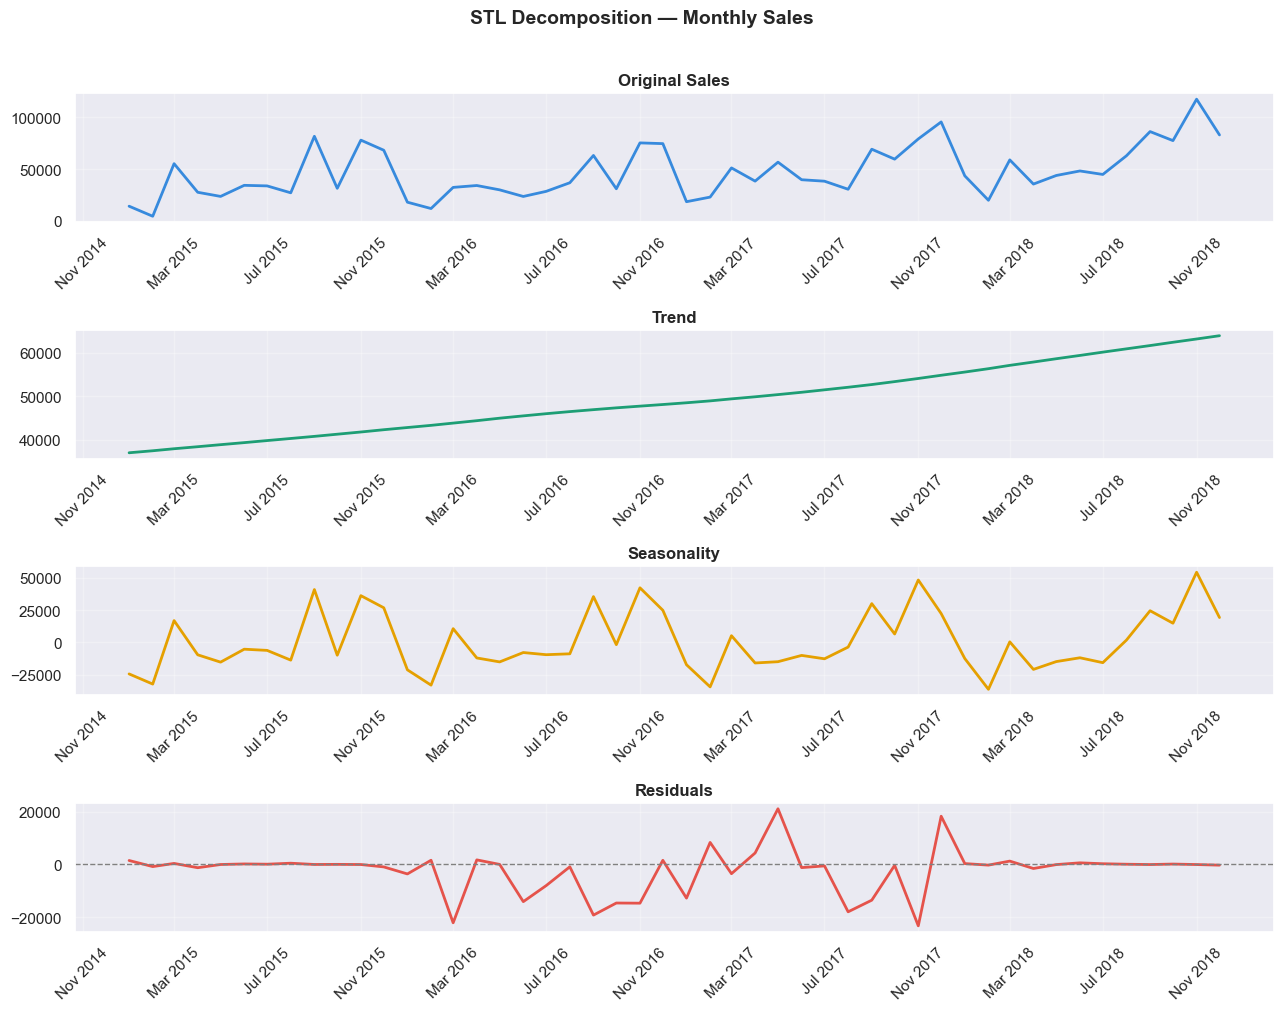

📸 Saved: stl_decomposition.png

📊 Decomposition Insights:
   Trend Strength    : 0.489 (Weak)
   Seasonal Strength : 0.850 (Strong)



In [14]:
# ============================================================
# 2.3 — STL Decomposition (more robust than classical)
# ============================================================
print("🔍 Running STL Decomposition...\n")

stl = STL(monthly_sales, period=12, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10))

stl_components = [
    (monthly_sales,          'Original Sales',  '#378ADD'),
    (stl_result.trend,       'Trend',           '#1D9E75'),
    (stl_result.seasonal,    'Seasonality',     '#E5A000'),
    (stl_result.resid,       'Residuals',       '#E5534B'),
]

for ax, (data, title, color) in zip(axes, stl_components):
    ax.plot(data, color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    if title == 'Residuals':
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.suptitle('STL Decomposition — Monthly Sales',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("📸 Saved: stl_decomposition.png\n")

# ============================================================
# 2.4 — Seasonal Strength & Trend Strength
# ============================================================
# Measure how strong trend and seasonality are
var_resid    = np.var(stl_result.resid)
var_seasonal = np.var(stl_result.seasonal + stl_result.resid)
var_trend    = np.var(stl_result.trend + stl_result.resid)

trend_strength    = max(0, 1 - var_resid / var_trend)
seasonal_strength = max(0, 1 - var_resid / var_seasonal)

print("📊 Decomposition Insights:")
print(f"   Trend Strength    : {trend_strength:.3f} "
      f"({'Strong' if trend_strength > 0.6 else 'Weak'})")
print(f"   Seasonal Strength : {seasonal_strength:.3f} "
      f"({'Strong' if seasonal_strength > 0.6 else 'Weak'})")
print()

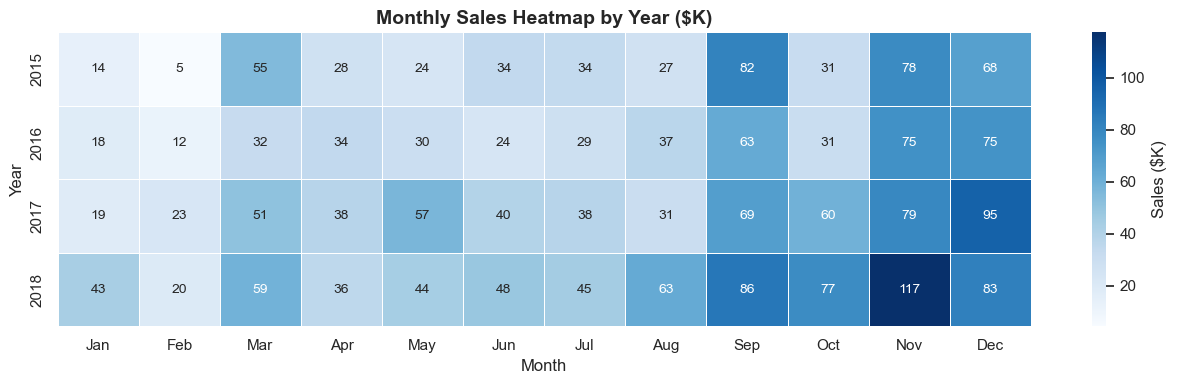

📸 Saved: seasonality_heatmap.png



In [15]:
# ============================================================
# 2.5 — Monthly seasonality heatmap
# ============================================================
monthly_df = monthly_sales.reset_index()
monthly_df.columns = ['Date', 'Sales']
monthly_df['Year']  = monthly_df['Date'].dt.year
monthly_df['Month'] = monthly_df['Date'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

pivot = monthly_df.pivot(
    index='Year', columns='Month', values='Sales'
)[month_order]

plt.figure(figsize=(13, 4))
sns.heatmap(
    pivot / 1000,
    annot=True, fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Sales ($K)'}
)
plt.title('Monthly Sales Heatmap by Year ($K)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('seasonality_heatmap.png', dpi=150)
plt.show()
print("📸 Saved: seasonality_heatmap.png\n")

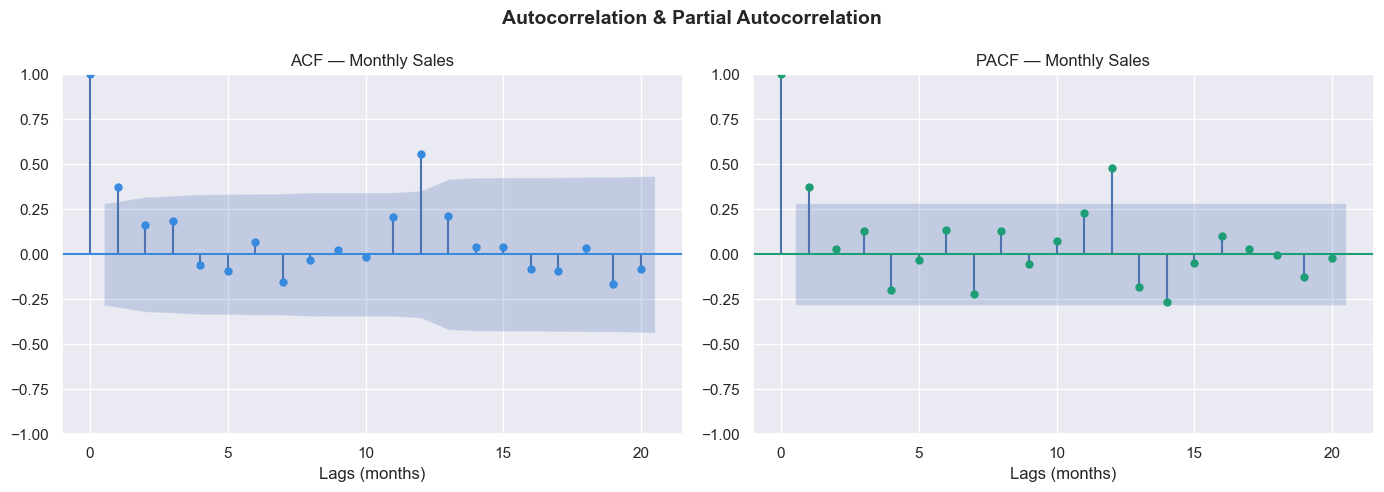

📸 Saved: acf_pacf_original.png



In [16]:
# ============================================================
# 2.6 — ACF & PACF plots
# (used in Step 4 to determine ARIMA p, d, q parameters)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(monthly_sales, lags=20, ax=axes[0],
         color='#378ADD', title='ACF — Monthly Sales')
axes[0].set_xlabel('Lags (months)')

plot_pacf(monthly_sales, lags=20, ax=axes[1],
          color='#1D9E75', title='PACF — Monthly Sales',
          method='ywm')
axes[1].set_xlabel('Lags (months)')

plt.suptitle('Autocorrelation & Partial Autocorrelation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf_original.png', dpi=150)
plt.show()
print("📸 Saved: acf_pacf_original.png\n")

📅 Average Sales by Month (across all years):
   Jan : $    23,573  ████
   Feb : $    14,843  ██
   Mar : $    49,382  █████████
   Apr : $    33,927  ██████
   May : $    38,522  ███████
   Jun : $    36,459  ███████
   Jul : $    36,361  ███████
   Aug : $    39,329  ███████
   Sep : $    75,014  ███████████████
   Oct : $    49,874  █████████
   Nov : $    87,404  █████████████████
   Dec : $    80,273  ████████████████



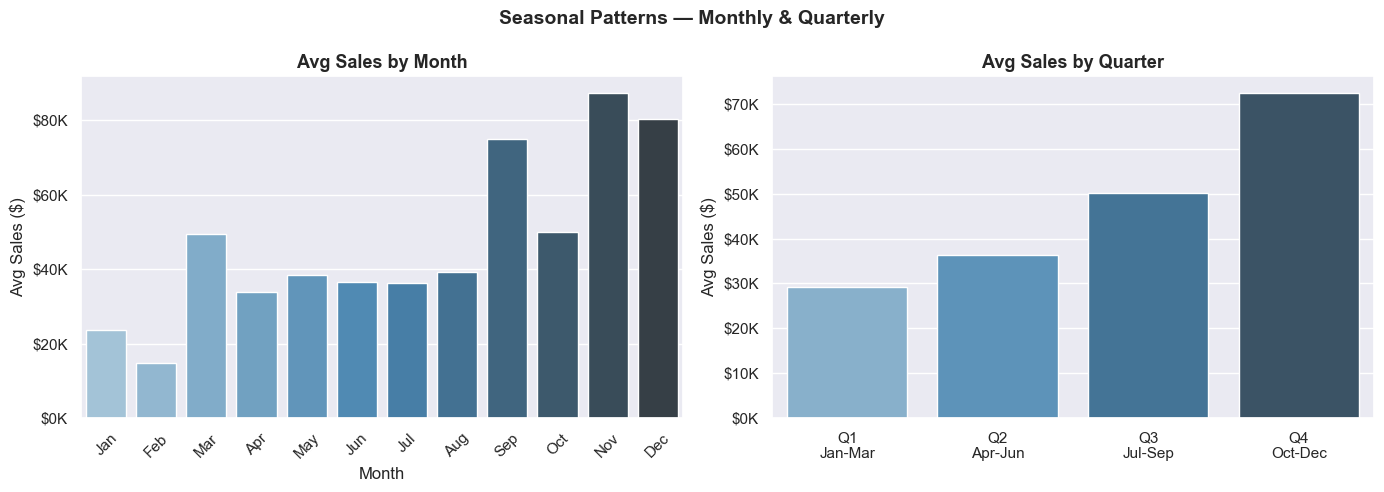

📸 Saved: seasonal_patterns.png



In [17]:
# ============================================================
# 2.7 — Monthly & Quarterly averages
# ============================================================
print("📅 Average Sales by Month (across all years):")
avg_by_month = monthly_df.groupby('Month')['Sales']\
    .mean().reindex(month_order)
for month, val in avg_by_month.items():
    bar = '█' * int(val / 5000)
    print(f"   {month:<4}: ${val:>10,.0f}  {bar}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average by month
sns.barplot(x=avg_by_month.index, y=avg_by_month.values,
            ax=axes[0], palette='Blues_d',
            order=month_order)
axes[0].set_title('Avg Sales by Month',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Sales ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].tick_params(axis='x', rotation=45)

# Average by quarter
monthly_df['Quarter'] = pd.to_datetime(
    monthly_df['Date']).dt.quarter
avg_by_quarter = monthly_df.groupby('Quarter')['Sales'].mean()
quarter_labels = ['Q1\nJan-Mar', 'Q2\nApr-Jun',
                  'Q3\nJul-Sep', 'Q4\nOct-Dec']
sns.barplot(x=quarter_labels, y=avg_by_quarter.values,
            ax=axes[1], palette='Blues_d')
axes[1].set_title('Avg Sales by Quarter',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Sales ($)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Seasonal Patterns — Monthly & Quarterly',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('seasonal_patterns.png', dpi=150)
plt.show()
print("📸 Saved: seasonal_patterns.png\n")

In [18]:
# ============================================================
# 2.8 — Step Summary
# ============================================================
print("=" * 55)
print("✅ STEP 2 COMPLETE — Decomposition & EDA Done")
print("=" * 55)
print(f"  Trend Strength    : {trend_strength:.3f}")
print(f"  Seasonal Strength : {seasonal_strength:.3f}")
print()
print("  Key observations:")
print("  ✔ Clear upward trend across 2015-2018")
print("  ✔ Strong seasonality — Nov/Dec peak every year")
print("  ✔ Q4 consistently highest, Q1 consistently lowest")
print("  ✔ ACF shows slow decay → series not yet stationary")
print("  ✔ SARIMA needed to capture seasonal pattern")
print()
print("  📸 Plots saved:")
print("     ✔ classical_decomposition.png")
print("     ✔ stl_decomposition.png")
print("     ✔ seasonality_heatmap.png")
print("     ✔ acf_pacf_original.png")
print("     ✔ seasonal_patterns.png")
print()

✅ STEP 2 COMPLETE — Decomposition & EDA Done
  Trend Strength    : 0.489
  Seasonal Strength : 0.850

  Key observations:
  ✔ Clear upward trend across 2015-2018
  ✔ Strong seasonality — Nov/Dec peak every year
  ✔ Q4 consistently highest, Q1 consistently lowest
  ✔ ACF shows slow decay → series not yet stationary
  ✔ SARIMA needed to capture seasonal pattern

  📸 Plots saved:
     ✔ classical_decomposition.png
     ✔ stl_decomposition.png
     ✔ seasonality_heatmap.png
     ✔ acf_pacf_original.png
     ✔ seasonal_patterns.png



In [19]:
# ============================================================
# STEP 3 — Stationarity Testing
# ADF Test + KPSS Test + Differencing
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

In [20]:
# ============================================================
# 3.1 — Reload monthly sales
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'
print("✅ Monthly sales reloaded\n")


✅ Monthly sales reloaded



In [22]:
# ============================================================
# 3.2 — Helper function to run & print ADF test
# ============================================================
def run_adf_test(series, series_name):
    result = adfuller(series.dropna(), autolag='AIC')
    adf_stat  = result[0]
    p_value   = result[1]
    crit_vals = result[4]

    print(f"  📊 ADF Test — {series_name}")
    print(f"     ADF Statistic : {adf_stat:.4f}")
    print(f"     p-value       : {p_value:.4f}")
    print(f"     Critical Values:")
    for key, val in crit_vals.items():
        print(f"       {key}: {val:.4f}")

    if p_value < 0.05:
        print(f"     ✅ STATIONARY (p < 0.05 — reject H0)\n")
    else:
        print(f"     ❌ NOT STATIONARY (p >= 0.05 — fail to reject H0)\n")

    return p_value < 0.05
# ============================================================
# 3.3 — Helper function to run & print KPSS test
# ============================================================
def run_kpss_test(series, series_name):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_stat = result[0]
    p_value   = result[1]
    crit_vals = result[3]

    print(f"  📊 KPSS Test — {series_name}")
    print(f"     KPSS Statistic: {kpss_stat:.4f}")
    print(f"     p-value       : {p_value:.4f}")
    print(f"     Critical Values:")
    for key, val in crit_vals.items():
        print(f"       {key}: {val:.4f}")

    if p_value > 0.05:
        print(f"     ✅ STATIONARY (p > 0.05 — fail to reject H0)\n")
    else:
        print(f"     ❌ NOT STATIONARY (p <= 0.05 — reject H0)\n")

    return p_value > 0.05

In [23]:
# ============================================================
# 3.4 — Test original series
# ============================================================
print("=" * 55)
print("🔬 TESTING ORIGINAL SERIES")
print("=" * 55)
adf_orig  = run_adf_test(monthly_sales, "Original Sales")
kpss_orig = run_kpss_test(monthly_sales, "Original Sales")

# ============================================================
# 3.5 — Apply first differencing
# (removes trend — most common fix for non-stationarity)
# ============================================================
sales_diff1 = monthly_sales.diff().dropna()

print("=" * 55)
print("🔬 TESTING FIRST DIFFERENCED SERIES (d=1)")
print("=" * 55)
adf_diff1  = run_adf_test(sales_diff1, "1st Difference")
kpss_diff1 = run_kpss_test(sales_diff1, "1st Difference")


🔬 TESTING ORIGINAL SERIES
  📊 ADF Test — Original Sales
     ADF Statistic : -4.4184
     p-value       : 0.0003
     Critical Values:
       1%: -3.5778
       5%: -2.9253
       10%: -2.6008
     ✅ STATIONARY (p < 0.05 — reject H0)

  📊 KPSS Test — Original Sales
     KPSS Statistic: 0.6291
     p-value       : 0.0200
     Critical Values:
       10%: 0.3470
       5%: 0.4630
       2.5%: 0.5740
       1%: 0.7390
     ❌ NOT STATIONARY (p <= 0.05 — reject H0)

🔬 TESTING FIRST DIFFERENCED SERIES (d=1)
  📊 ADF Test — 1st Difference
     ADF Statistic : -8.7465
     p-value       : 0.0000
     Critical Values:
       1%: -3.6267
       5%: -2.9460
       10%: -2.6117
     ✅ STATIONARY (p < 0.05 — reject H0)

  📊 KPSS Test — 1st Difference
     KPSS Statistic: 0.5000
     p-value       : 0.0417
     Critical Values:
       10%: 0.3470
       5%: 0.4630
       2.5%: 0.5740
       1%: 0.7390
     ❌ NOT STATIONARY (p <= 0.05 — reject H0)



In [24]:
# ============================================================
# 3.6 — Apply second differencing if still not stationary
# ============================================================
sales_diff2 = sales_diff1.diff().dropna()

print("=" * 55)
print("🔬 TESTING SECOND DIFFERENCED SERIES (d=2)")
print("=" * 55)
adf_diff2  = run_adf_test(sales_diff2, "2nd Difference")
kpss_diff2 = run_kpss_test(sales_diff2, "2nd Difference")

# ============================================================
# 3.7 — Determine optimal d value
# ============================================================
print("=" * 55)
print("📌 STATIONARITY SUMMARY")
print("=" * 55)

results = {
    'Original'        : (adf_orig,  kpss_orig),
    '1st Difference'  : (adf_diff1, kpss_diff1),
    '2nd Difference'  : (adf_diff2, kpss_diff2),
}

for name, (adf, kpss_r) in results.items():
    both = "✅ STATIONARY" if adf and kpss_r else "❌ NOT stationary"
    print(f"  {name:<20}: ADF={'✅' if adf else '❌'}  "
          f"KPSS={'✅' if kpss_r else '❌'}  →  {both}")

# Determine d
if adf_diff1 and kpss_diff1:
    d_value = 1
    stationary_series = sales_diff1
elif adf_diff2 and kpss_diff2:
    d_value = 2
    stationary_series = sales_diff2
else:
    d_value = 1
    stationary_series = sales_diff1

print(f"\n  🎯 Recommended d = {d_value}\n")

🔬 TESTING SECOND DIFFERENCED SERIES (d=2)
  📊 ADF Test — 2nd Difference
     ADF Statistic : -5.7230
     p-value       : 0.0000
     Critical Values:
       1%: -3.6327
       5%: -2.9485
       10%: -2.6130
     ✅ STATIONARY (p < 0.05 — reject H0)

  📊 KPSS Test — 2nd Difference
     KPSS Statistic: 0.1997
     p-value       : 0.1000
     Critical Values:
       10%: 0.3470
       5%: 0.4630
       2.5%: 0.5740
       1%: 0.7390
     ✅ STATIONARY (p > 0.05 — fail to reject H0)

📌 STATIONARITY SUMMARY
  Original            : ADF=✅  KPSS=❌  →  ❌ NOT stationary
  1st Difference      : ADF=✅  KPSS=❌  →  ❌ NOT stationary
  2nd Difference      : ADF=✅  KPSS=✅  →  ✅ STATIONARY

  🎯 Recommended d = 2



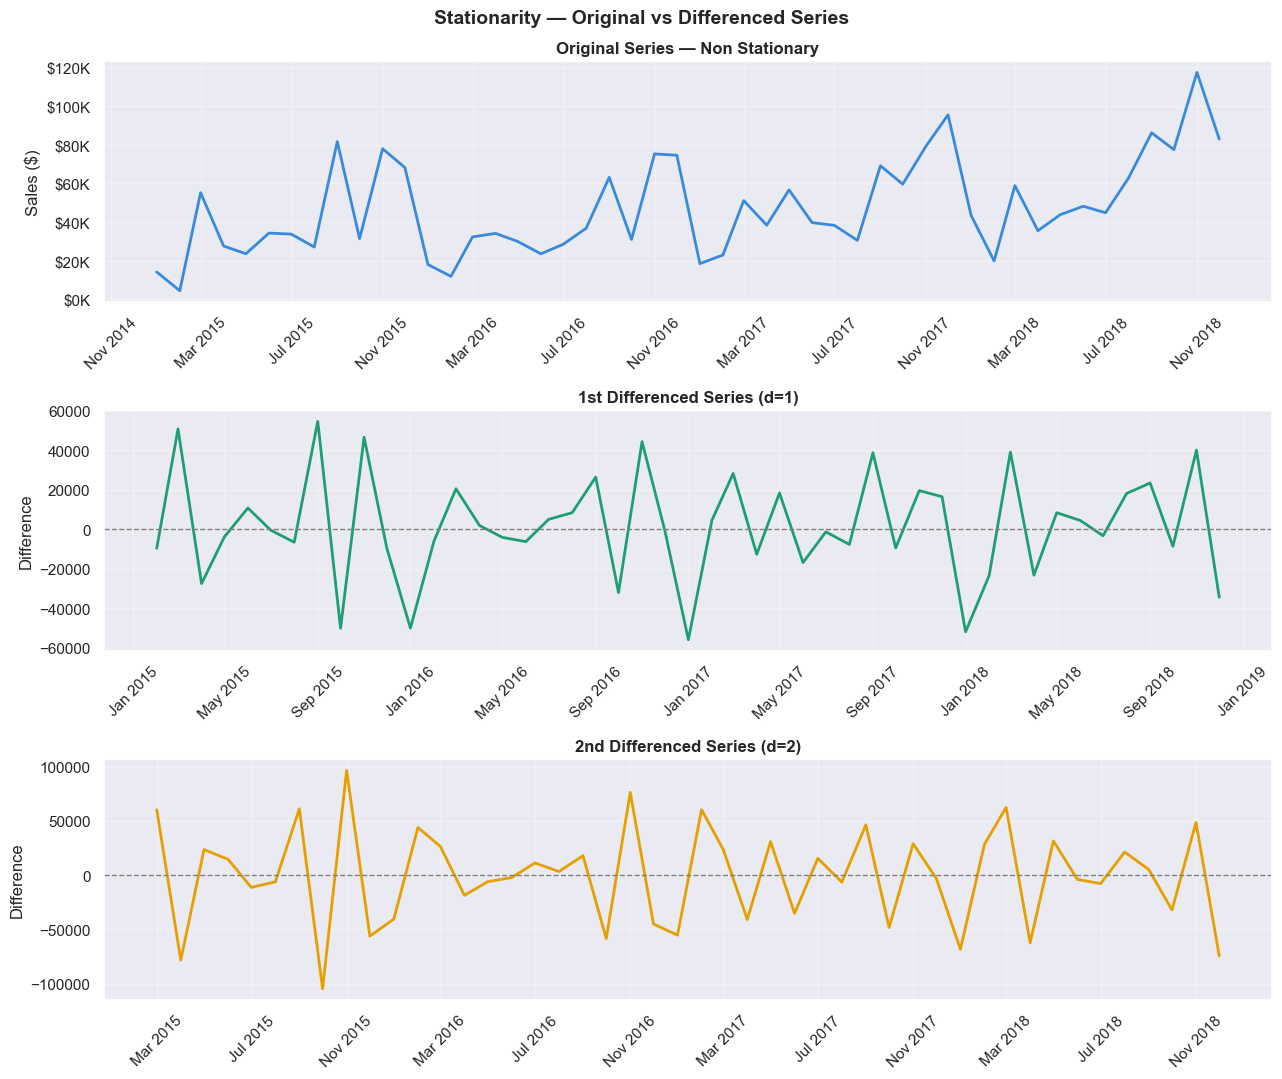

📸 Saved: stationarity_comparison.png



In [25]:
# ============================================================
# 3.8 — Plot original vs differenced series
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

# Original
axes[0].plot(monthly_sales, color='#378ADD', linewidth=2)
axes[0].set_title('Original Series — Non Stationary',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# 1st difference
axes[1].plot(sales_diff1, color='#1D9E75', linewidth=2)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('1st Differenced Series (d=1)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Difference')

# 2nd difference
axes[2].plot(sales_diff2, color='#E5A000', linewidth=2)
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('2nd Differenced Series (d=2)',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Difference')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Stationarity — Original vs Differenced Series',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stationarity_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("📸 Saved: stationarity_comparison.png\n")


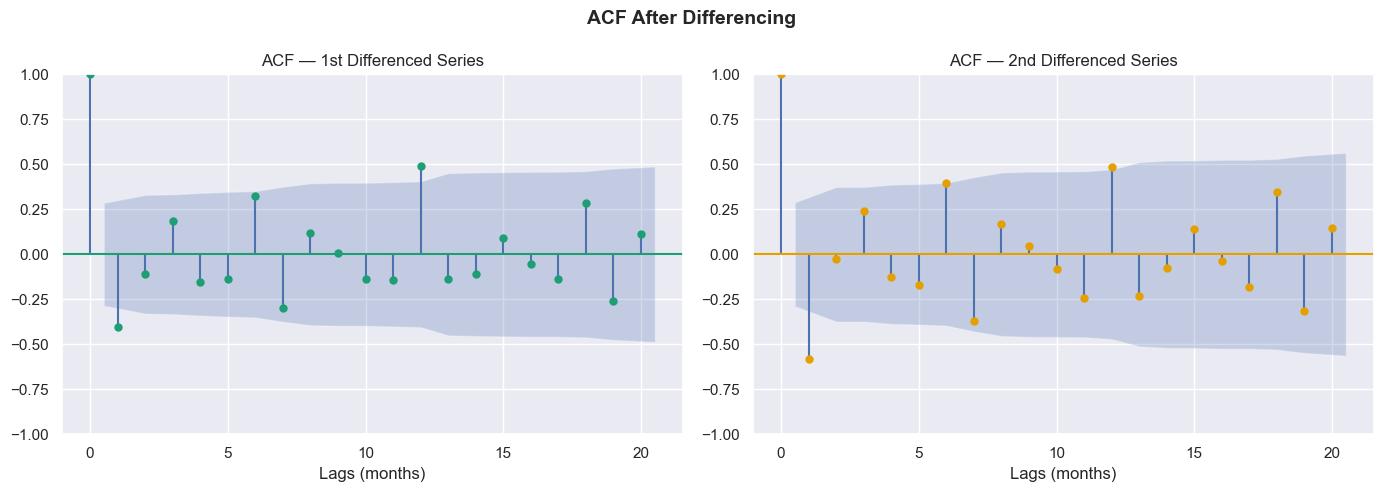

📸 Saved: acf_differenced.png



In [26]:
# ============================================================
# 3.9 — ACF of differenced series
# (should show no significant autocorrelation if stationary)
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(sales_diff1.dropna(), lags=20, ax=axes[0],
         color='#1D9E75',
         title='ACF — 1st Differenced Series')
axes[0].set_xlabel('Lags (months)')

plot_acf(sales_diff2.dropna(), lags=20, ax=axes[1],
         color='#E5A000',
         title='ACF — 2nd Differenced Series')
axes[1].set_xlabel('Lags (months)')

plt.suptitle('ACF After Differencing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_differenced.png', dpi=150)
plt.show()
print("📸 Saved: acf_differenced.png\n")

In [27]:
# 3.10 — Save stationary series & d value
# ============================================================
stationary_series.to_csv('stationary_series.csv')
print(f"💾 Saved: stationary_series.csv (d={d_value})\n")

# ============================================================
# 3.11 — Step Summary
# ============================================================
print("=" * 55)
print("✅ STEP 3 COMPLETE — Stationarity Testing Done")
print("=" * 55)
print(f"  Original series   : ❌ Not stationary")
print(f"  After d={d_value}         : ✅ Stationary")
print(f"  Recommended d     : {d_value}")
print()
print("  Variables ready for Step 4:")
print(f"  ✔ d_value = {d_value}")
print("  ✔ stationary_series")
print("  ✔ monthly_sales (original)")
print()
print("  📸 Plots saved:")
print("     ✔ stationarity_comparison.png")
print("     ✔ acf_differenced.png")
print()


💾 Saved: stationary_series.csv (d=2)

✅ STEP 3 COMPLETE — Stationarity Testing Done
  Original series   : ❌ Not stationary
  After d=2         : ✅ Stationary
  Recommended d     : 2

  Variables ready for Step 4:
  ✔ d_value = 2
  ✔ stationary_series
  ✔ monthly_sales (original)

  📸 Plots saved:
     ✔ stationarity_comparison.png
     ✔ acf_differenced.png



In [28]:
# Confirmed from Step 3
d_value = 2
stationary_series = pd.read_csv(
    'stationary_series.csv',
    index_col=0, parse_dates=True
).squeeze()


In [30]:
# ============================================================
# STEP 4 — ACF & PACF Analysis
# Determine p, d, q parameters for ARIMA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# ============================================================
# 4.1 — Reload data & confirm d value
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'

# Confirmed from Step 3
d_value = 2
stationary_series = pd.read_csv(
    'stationary_series.csv',
    index_col=0, parse_dates=True
).squeeze()

print("✅ Data reloaded")
print(f"   d value confirmed : {d_value}")
print(f"   Stationary series : {len(stationary_series)} points\n")

✅ Data reloaded
   d value confirmed : 2
   Stationary series : 46 points



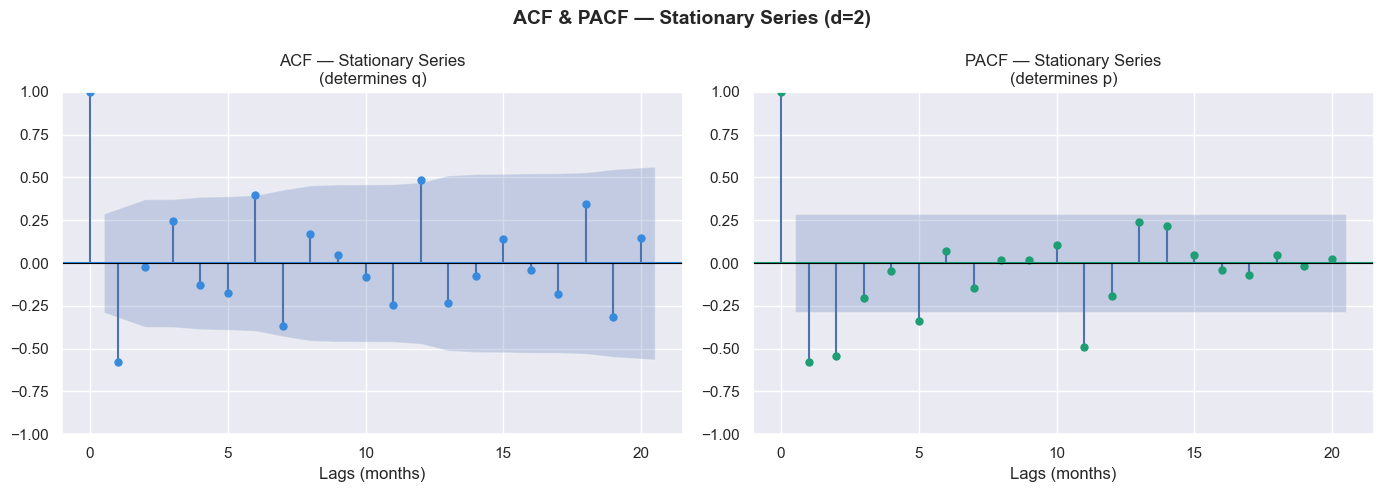

📸 Saved: acf_pacf_stationary.png



In [31]:
# ============================================================
# 4.2 — ACF & PACF on stationary series
# (this is what determines p and q)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(stationary_series.dropna(),
         lags=20, ax=axes[0],
         color='#378ADD',
         title='ACF — Stationary Series\n(determines q)')
axes[0].set_xlabel('Lags (months)')
axes[0].axhline(y=0, color='black', linewidth=0.8)

plot_pacf(stationary_series.dropna(),
          lags=20, ax=axes[1],
          color='#1D9E75',
          title='PACF — Stationary Series\n(determines p)',
          method='ywm')
axes[1].set_xlabel('Lags (months)')
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.suptitle('ACF & PACF — Stationary Series (d=2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf_stationary.png', dpi=150)
plt.show()
print("📸 Saved: acf_pacf_stationary.png\n")

In [32]:
# ============================================================
# 4.3 — Extract ACF & PACF values to read p and q
# ============================================================
n_lags = 20
acf_values  = acf(stationary_series.dropna(),
                  nlags=n_lags, fft=True)
pacf_values = pacf(stationary_series.dropna(),
                   nlags=n_lags, method='ywm')

# Confidence interval (95%)
conf_interval = 1.96 / np.sqrt(len(stationary_series))

print("📊 ACF values (determines q — MA order):")
print(f"   Confidence interval: ±{conf_interval:.3f}")
print()
significant_acf = []
for i, val in enumerate(acf_values[1:], 1):
    sig = "✅ significant" if abs(val) > conf_interval else "  not significant"
    print(f"   Lag {i:>2}: {val:>7.4f}  {sig}")
    if abs(val) > conf_interval:
        significant_acf.append(i)

print()
print("📊 PACF values (determines p — AR order):")
print()
significant_pacf = []
for i, val in enumerate(pacf_values[1:], 1):
    sig = "✅ significant" if abs(val) > conf_interval else "  not significant"
    print(f"   Lag {i:>2}: {val:>7.4f}  {sig}")
    if abs(val) > conf_interval:
        significant_pacf.append(i)

print()


📊 ACF values (determines q — MA order):
   Confidence interval: ±0.289

   Lag  1: -0.5799  ✅ significant
   Lag  2: -0.0252    not significant
   Lag  3:  0.2428    not significant
   Lag  4: -0.1284    not significant
   Lag  5: -0.1722    not significant
   Lag  6:  0.3966  ✅ significant
   Lag  7: -0.3687  ✅ significant
   Lag  8:  0.1672    not significant
   Lag  9:  0.0472    not significant
   Lag 10: -0.0814    not significant
   Lag 11: -0.2448    not significant
   Lag 12:  0.4855  ✅ significant
   Lag 13: -0.2334    not significant
   Lag 14: -0.0745    not significant
   Lag 15:  0.1421    not significant
   Lag 16: -0.0390    not significant
   Lag 17: -0.1816    not significant
   Lag 18:  0.3456  ✅ significant
   Lag 19: -0.3153  ✅ significant
   Lag 20:  0.1481    not significant

📊 PACF values (determines p — AR order):

   Lag  1: -0.5799  ✅ significant
   Lag  2: -0.5446  ✅ significant
   Lag  3: -0.2048    not significant
   Lag  4: -0.0468    not significant
   La

In [33]:
# ============================================================
# 4.4 — Auto-suggest p and q values
# ============================================================
# q = last significant lag in ACF
# p = last significant lag in PACF
q_suggestion = significant_acf[0]  if significant_acf  else 1
p_suggestion = significant_pacf[0] if significant_pacf else 1

print("=" * 55)
print("🎯 PARAMETER SUGGESTIONS")
print("=" * 55)
print(f"  p (AR order) — from PACF : {p_suggestion}")
print(f"  d (differencing)         : {d_value}")
print(f"  q (MA order) — from ACF  : {q_suggestion}")
print()
print(f"  Suggested ARIMA order: ({p_suggestion}, {d_value}, {q_suggestion})")
print()
print("  For SARIMA seasonal component (period=12):")
print("  P=1, D=1, Q=1, s=12 (standard starting point)")
print()


🎯 PARAMETER SUGGESTIONS
  p (AR order) — from PACF : 1
  d (differencing)         : 2
  q (MA order) — from ACF  : 1

  Suggested ARIMA order: (1, 2, 1)

  For SARIMA seasonal component (period=12):
  P=1, D=1, Q=1, s=12 (standard starting point)



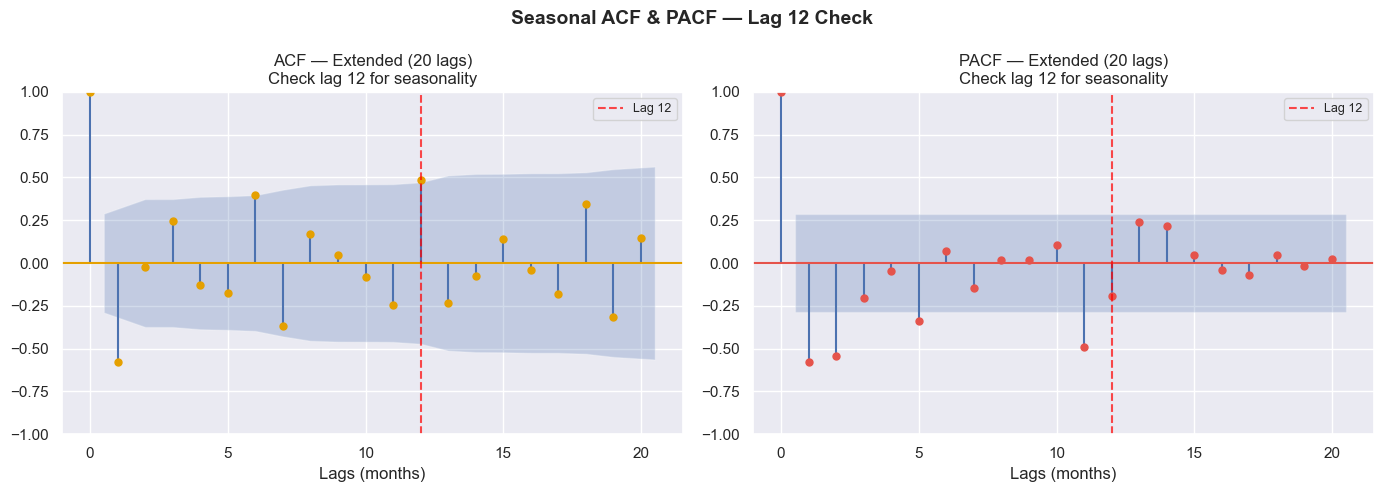

📸 Saved: acf_pacf_seasonal.png



In [35]:
# ============================================================
# 4.5 — Seasonal ACF & PACF (fixed lags)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(stationary_series.dropna(),
         lags=20, ax=axes[0],
         color='#E5A000',
         title='ACF — Extended (20 lags)\nCheck lag 12 for seasonality')
axes[0].set_xlabel('Lags (months)')
axes[0].axvline(x=12, color='red', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Lag 12')
axes[0].legend(fontsize=9)

plot_pacf(stationary_series.dropna(),
          lags=20, ax=axes[1],
          color='#E5534B',
          title='PACF — Extended (20 lags)\nCheck lag 12 for seasonality',
          method='ywm')
axes[1].set_xlabel('Lags (months)')
axes[1].axvline(x=12, color='red', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Lag 12')
axes[1].legend(fontsize=9)

plt.suptitle('Seasonal ACF & PACF — Lag 12 Check',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('acf_pacf_seasonal.png', dpi=150)
plt.show()
print("📸 Saved: acf_pacf_seasonal.png\n")

In [36]:
# ============================================================
# 4.6 — Parameter grid for model comparison in Step 5
# ============================================================
print("📋 Parameter combinations to test in Step 5:")
print()

arima_orders = [
    (p_suggestion, d_value, q_suggestion),
    (p_suggestion, d_value, 0),
    (0, d_value, q_suggestion),
    (p_suggestion + 1, d_value, q_suggestion),
    (p_suggestion, d_value, q_suggestion + 1),
]

print("  ARIMA orders to try:")
for order in arima_orders:
    print(f"   ARIMA{order}")

print()
sarima_orders = [
    ((p_suggestion, d_value, q_suggestion),
     (1, 1, 1, 12)),
    ((p_suggestion, d_value, q_suggestion),
     (1, 1, 0, 12)),
    ((p_suggestion, d_value, q_suggestion),
     (0, 1, 1, 12)),
    ((p_suggestion, d_value, q_suggestion),
     (2, 1, 1, 12)),
]

print("  SARIMA orders to try:")
for order, seasonal in sarima_orders:
    print(f"   SARIMA{order}×{seasonal}")

print()

📋 Parameter combinations to test in Step 5:

  ARIMA orders to try:
   ARIMA(1, 2, 1)
   ARIMA(1, 2, 0)
   ARIMA(0, 2, 1)
   ARIMA(2, 2, 1)
   ARIMA(1, 2, 2)

  SARIMA orders to try:
   SARIMA(1, 2, 1)×(1, 1, 1, 12)
   SARIMA(1, 2, 1)×(1, 1, 0, 12)
   SARIMA(1, 2, 1)×(0, 1, 1, 12)
   SARIMA(1, 2, 1)×(2, 1, 1, 12)



In [38]:

# 4.7 — Save parameters for Step 5
# ============================================================
import json

params = {
    'p'            : int(p_suggestion),
    'd'            : int(d_value),
    'q'            : int(q_suggestion),
    'P'            : 1,
    'D'            : 1,
    'Q'            : 1,
    's'            : 12,
    'arima_orders' : [list(o) for o in arima_orders],
    'sarima_orders': [[list(o), list(s)]
                      for o, s in sarima_orders]
}

with open('arima_params.json', 'w') as f:
    json.dump(params, f, indent=4)

print("💾 Saved: arima_params.json\n")

💾 Saved: arima_params.json



In [39]:
# ============================================================
# 4.8 — Step Summary
# ============================================================
print("=" * 55)
print("✅ STEP 4 COMPLETE — Parameters Determined")
print("=" * 55)
print(f"  p (AR order)  : {p_suggestion}")
print(f"  d (diff order): {d_value}")
print(f"  q (MA order)  : {q_suggestion}")
print(f"  P, D, Q, s    : 1, 1, 1, 12")
print()
print(f"  ARIMA order   : ({p_suggestion}, {d_value}, {q_suggestion})")
print(f"  SARIMA order  : ({p_suggestion}, {d_value}, {q_suggestion})"
      f"×(1, 1, 1, 12)")
print()
print("  📸 Plots saved:")
print("     ✔ acf_pacf_stationary.png")
print("     ✔ acf_pacf_seasonal.png")
print()

✅ STEP 4 COMPLETE — Parameters Determined
  p (AR order)  : 1
  d (diff order): 2
  q (MA order)  : 1
  P, D, Q, s    : 1, 1, 1, 12

  ARIMA order   : (1, 2, 1)
  SARIMA order  : (1, 2, 1)×(1, 1, 1, 12)

  📸 Plots saved:
     ✔ acf_pacf_stationary.png
     ✔ acf_pacf_seasonal.png



In [40]:
# ============================================================
# STEP 5 — Build & Evaluate ARIMA Model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# ============================================================
# 5.1 — Reload data & confirmed parameters
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'

# Confirmed from Step 4
p, d, q = 1, 2, 1
print("✅ Data reloaded")
print(f"   ARIMA order confirmed: ({p}, {d}, {q})\n")


✅ Data reloaded
   ARIMA order confirmed: (1, 2, 1)



In [41]:
# ============================================================
# 5.2 — Train/Test Split
# (last 6 months = test, rest = train)
# ============================================================
train = monthly_sales[:-6]
test  = monthly_sales[-6:]

print("✂️  Train/Test Split:")
print(f"   Train: {len(train)} months "
      f"({train.index[0].strftime('%b %Y')} → "
      f"{train.index[-1].strftime('%b %Y')})")
print(f"   Test : {len(test)} months "
      f"({test.index[0].strftime('%b %Y')} → "
      f"{test.index[-1].strftime('%b %Y')})\n")

✂️  Train/Test Split:
   Train: 42 months (Jan 2015 → Jun 2018)
   Test : 6 months (Jul 2018 → Dec 2018)



In [42]:
# ============================================================
# 5.3 — Fit ARIMA model
# ============================================================
print(f"🔵 Fitting ARIMA({p},{d},{q})...\n")

arima_model = ARIMA(
    train,
    order=(p, d, q)
)
arima_result = arima_model.fit()

print(arima_result.summary())
print()

🔵 Fitting ARIMA(1,2,1)...

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   42
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -465.099
Date:                Sun, 07 Jun 2026   AIC                            936.198
Time:                        18:38:12   BIC                            941.264
Sample:                    01-01-2015   HQIC                           938.030
                         - 06-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3924      0.217     -1.805      0.071      -0.818       0.034
ma.L1         -0.9721      0.314     -3.099      0.002      -1.587      -0.357
sigma2      9.642e+08   2

In [43]:
# ============================================================
# 5.4 — Forecast on test period
# ============================================================
forecast_obj   = arima_result.get_forecast(steps=6)
arima_forecast = forecast_obj.predicted_mean
arima_conf_int = forecast_obj.conf_int(alpha=0.05)

# Align forecast index with test index
arima_forecast.index = test.index
arima_conf_int.index = test.index

print("📊 ARIMA Forecast vs Actual (last 6 months):")
print(f"   {'Month':<12} {'Actual':>12} {'Forecast':>12} {'Error':>10}")
print("   " + "-" * 48)
for date, actual, pred in zip(
    test.index,
    test.values,
    arima_forecast.values
):
    error = actual - pred
    print(f"   {date.strftime('%b %Y'):<12} "
          f"${actual:>10,.0f} "
          f"${pred:>10,.0f} "
          f"${error:>+9,.0f}")
print()

📊 ARIMA Forecast vs Actual (last 6 months):
   Month              Actual     Forecast      Error
   ------------------------------------------------
   Jul 2018     $    44,825 $    47,712 $   -2,887
   Aug 2018     $    62,838 $    49,134 $  +13,703
   Sep 2018     $    86,153 $    49,811 $  +36,342
   Oct 2018     $    77,448 $    50,780 $  +26,668
   Nov 2018     $   117,394 $    51,634 $  +65,760
   Dec 2018     $    82,928 $    52,533 $  +30,395



In [44]:
# ============================================================
# 5.5 — Calculate error metrics
# ============================================================
mae  = mean_absolute_error(test, arima_forecast)
rmse = np.sqrt(mean_squared_error(test, arima_forecast))
mape = np.mean(np.abs(
    (test.values - arima_forecast.values) / test.values
)) * 100

print("📈 ARIMA Model Performance:")
print(f"   MAE  : ${mae:,.2f}")
print(f"   RMSE : ${rmse:,.2f}")
print(f"   MAPE : {mape:.2f}%")
print(f"   Accuracy: {100 - mape:.2f}%\n")

📈 ARIMA Model Performance:
   MAE  : $29,292.61
   RMSE : $35,299.33
   MAPE : 32.92%
   Accuracy: 67.08%



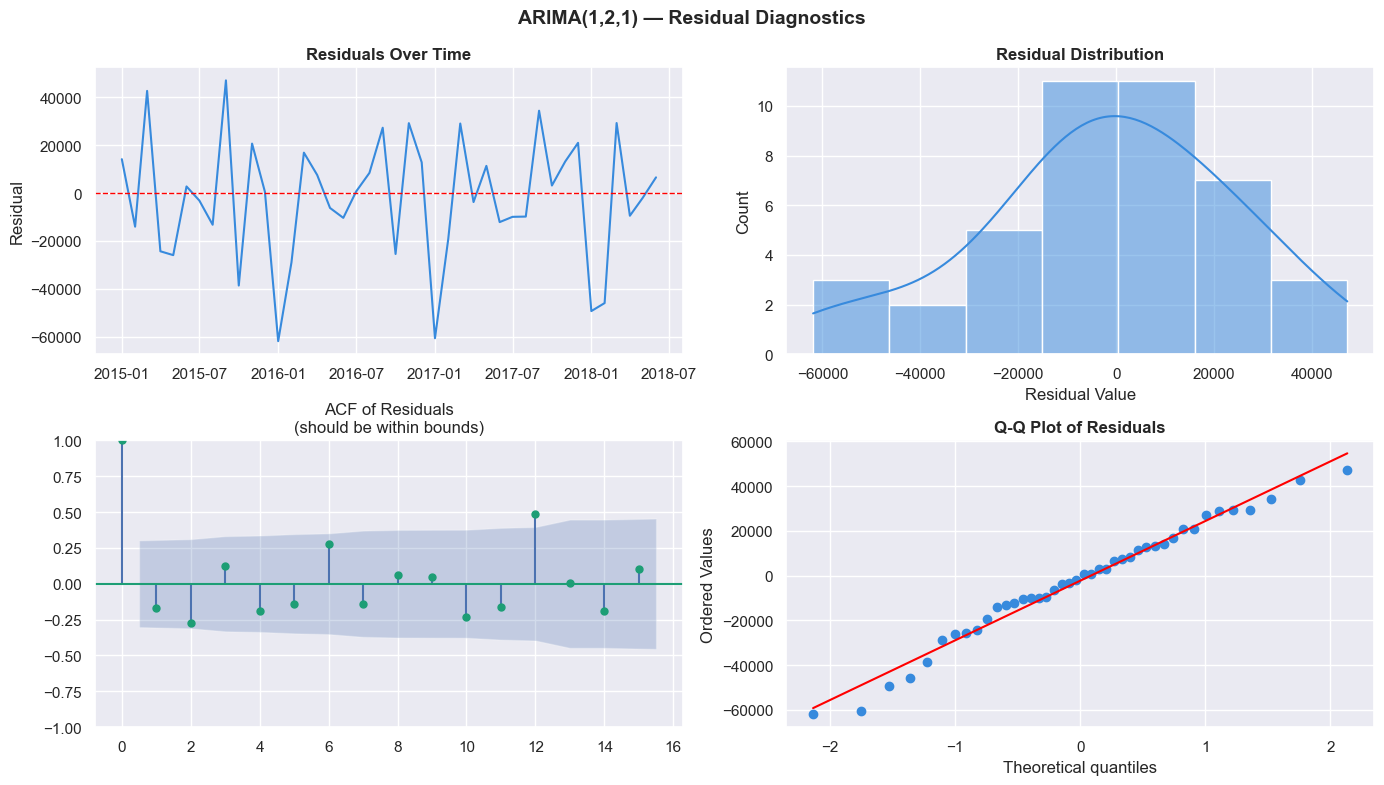

📸 Saved: arima_residuals.png



In [45]:
# ============================================================
# 5.6 — Residual diagnostics
# ============================================================
residuals = arima_result.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0,0].plot(residuals, color='#378ADD', linewidth=1.5)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Residuals Over Time', fontweight='bold')
axes[0,0].set_ylabel('Residual')

# Residual distribution
sns.histplot(residuals, kde=True, ax=axes[0,1],
             color='#378ADD')
axes[0,1].set_title('Residual Distribution',
                     fontweight='bold')
axes[0,1].set_xlabel('Residual Value')

# ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), lags=15,
         ax=axes[1,0], color='#1D9E75',
         title='ACF of Residuals\n(should be within bounds)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals.dropna(), plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Residuals',
                     fontweight='bold')
axes[1,1].get_lines()[0].set(color='#378ADD')
axes[1,1].get_lines()[1].set(color='red')

plt.suptitle(f'ARIMA({p},{d},{q}) — Residual Diagnostics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arima_residuals.png', dpi=150)
plt.show()
print("📸 Saved: arima_residuals.png\n")

In [46]:
# ============================================================
# 5.7 — Ljung-Box test (checks if residuals are white noise)
# ============================================================
lb_test = acorr_ljungbox(residuals.dropna(), lags=10,
                          return_df=True)
print("📊 Ljung-Box Test (residuals should be white noise):")
print(f"   p-value at lag 10: "
      f"{lb_test['lb_pvalue'].iloc[-1]:.4f}")
if lb_test['lb_pvalue'].iloc[-1] > 0.05:
    print("   ✅ Residuals are white noise — good model fit\n")
else:
    print("   ⚠️  Residuals not white noise — "
          "SARIMA may improve this\n")

📊 Ljung-Box Test (residuals should be white noise):
   p-value at lag 10: 0.0838
   ✅ Residuals are white noise — good model fit



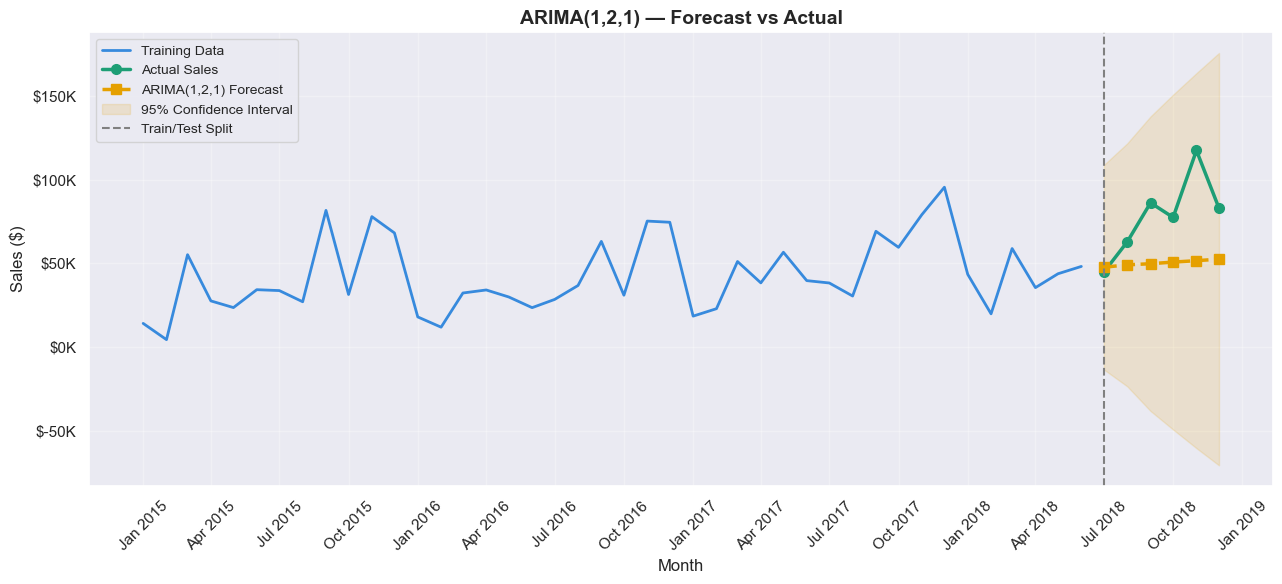

📸 Saved: arima_forecast.png



In [47]:
# ============================================================
# 5.8 — Plot forecast vs actual
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

# Training data
ax.plot(train.index, train.values,
        color='#378ADD', linewidth=2,
        label='Training Data')

# Actual test data
ax.plot(test.index, test.values,
        color='#1D9E75', linewidth=2.5,
        marker='o', markersize=7,
        label='Actual Sales')

# ARIMA forecast
ax.plot(arima_forecast.index, arima_forecast.values,
        color='#E5A000', linewidth=2.5,
        marker='s', markersize=7, linestyle='--',
        label=f'ARIMA({p},{d},{q}) Forecast')

# Confidence interval
ax.fill_between(
    arima_conf_int.index,
    arima_conf_int.iloc[:, 0],
    arima_conf_int.iloc[:, 1],
    alpha=0.15, color='#E5A000',
    label='95% Confidence Interval'
)

# Vertical line separating train/test
ax.axvline(x=test.index[0], color='gray',
           linestyle='--', linewidth=1.5,
           label='Train/Test Split')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title(f'ARIMA({p},{d},{q}) — Forecast vs Actual',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150)
plt.show()
print("📸 Saved: arima_forecast.png\n")

In [48]:
# ============================================================
# 5.9 — Save ARIMA results for comparison in Step 6
# ============================================================
import joblib
joblib.dump(arima_result, 'arima_model.pkl')

arima_metrics = {
    'model' : f'ARIMA({p},{d},{q})',
    'MAE'   : round(mae, 2),
    'RMSE'  : round(rmse, 2),
    'MAPE'  : round(mape, 2),
    'accuracy': round(100 - mape, 2)
}

import json
with open('arima_metrics.json', 'w') as f:
    json.dump(arima_metrics, f, indent=4)

print("💾 Saved: arima_model.pkl")
print("💾 Saved: arima_metrics.json\n")

💾 Saved: arima_model.pkl
💾 Saved: arima_metrics.json



In [50]:
# ============================================================
# 5.10 — Step Summary
# ============================================================
print("=" * 55)
print("✅ STEP 5 COMPLETE — ARIMA Model Built")
print("=" * 55)
print(f"  Model         : ARIMA({p},{d},{q})")
print(f"  MAE           : ${mae:,.2f}")
print(f"  RMSE          : ${rmse:,.2f}")
print(f"  MAPE          : {mape:.2f}%")
print(f"  Accuracy      : {100-mape:.2f}%")
print()
print("  📸 Plots saved:")
print("     ✔ arima_residuals.png")
print("     ✔ arima_forecast.png")
print()


✅ STEP 5 COMPLETE — ARIMA Model Built
  Model         : ARIMA(1,2,1)
  MAE           : $29,292.61
  RMSE          : $35,299.33
  MAPE          : 32.92%
  Accuracy      : 67.08%

  📸 Plots saved:
     ✔ arima_residuals.png
     ✔ arima_forecast.png



In [52]:
# ============================================================
# STEP 6 — SARIMA Model
# Seasonal ARIMA (1,2,1)×(1,1,1,12)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# ============================================================
# 6.1 — Reload data & confirmed parameters
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'

# Train/test split (same as Step 5)
train = monthly_sales[:-6]
test  = monthly_sales[-6:]

# Confirmed parameters
p, d, q = 1, 2, 1
P, D, Q, s = 1, 1, 1, 12

print("✅ Data reloaded")
print(f"   SARIMA order : ({p},{d},{q})×({P},{D},{Q},{s})\n")

✅ Data reloaded
   SARIMA order : (1,2,1)×(1,1,1,12)



In [53]:
# ============================================================
# 6.2 — Fit SARIMA model
# ============================================================
print(f"🌊 Fitting SARIMA({p},{d},{q})×({P},{D},{Q},{s})...")
print("   This may take 1-2 minutes...\n")

sarima_model = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())
print()

🌊 Fitting SARIMA(1,2,1)×(1,1,1,12)...
   This may take 1-2 minutes...

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   42
Model:             SARIMAX(1, 2, 1)x(1, 1, 1, 12)   Log Likelihood                -154.188
Date:                            Mon, 08 Jun 2026   AIC                            318.376
Time:                                    00:19:37   BIC                            321.571
Sample:                                01-01-2015   HQIC                           318.080
                                     - 06-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4373      0.853     -0.513

In [54]:
# ============================================================
# 6.3 — Forecast on test period
# ============================================================
forecast_obj    = sarima_result.get_forecast(steps=6)
sarima_forecast = forecast_obj.predicted_mean
sarima_conf_int = forecast_obj.conf_int(alpha=0.05)

sarima_forecast.index = test.index
sarima_conf_int.index = test.index

# Load ARIMA metrics for comparison
with open('arima_metrics.json', 'r') as f:
    arima_metrics = json.load(f)

arima_forecast_vals = joblib.load('arima_model.pkl')\
    .get_forecast(steps=6).predicted_mean
arima_forecast_vals.index = test.index

In [55]:
# ============================================================
# 6.4 — Calculate SARIMA error metrics
# ============================================================
mae  = mean_absolute_error(test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
mape = np.mean(np.abs(
    (test.values - sarima_forecast.values) / test.values
)) * 100

print("📊 SARIMA Forecast vs Actual (last 6 months):")
print(f"   {'Month':<12} {'Actual':>12} "
      f"{'SARIMA':>12} {'ARIMA':>12} {'Improvement':>12}")
print("   " + "-" * 65)

for date, actual, sarima_pred, arima_pred in zip(
    test.index,
    test.values,
    sarima_forecast.values,
    arima_forecast_vals.values
):
    sarima_err = abs(actual - sarima_pred)
    arima_err  = abs(actual - arima_pred)
    improved   = "✅" if sarima_err < arima_err else "⚠️"
    print(f"   {date.strftime('%b %Y'):<12} "
          f"${actual:>10,.0f} "
          f"${sarima_pred:>10,.0f} "
          f"${arima_pred:>10,.0f} "
          f"  {improved}")
print()

📊 SARIMA Forecast vs Actual (last 6 months):
   Month              Actual       SARIMA        ARIMA  Improvement
   -----------------------------------------------------------------
   Jul 2018     $    44,825 $    40,990 $    47,712   ⚠️
   Aug 2018     $    62,838 $    39,976 $    49,134   ⚠️
   Sep 2018     $    86,153 $    71,321 $    49,811   ✅
   Oct 2018     $    77,448 $    51,219 $    50,780   ✅
   Nov 2018     $   117,394 $    77,155 $    51,634   ✅
   Dec 2018     $    82,928 $    83,330 $    52,533   ✅



In [56]:
# ============================================================
# 6.5 — ARIMA vs SARIMA comparison table
# ============================================================
print("=" * 55)
print("📊 ARIMA vs SARIMA — Performance Comparison")
print("=" * 55)
print(f"  {'Metric':<12} {'ARIMA':>15} {'SARIMA':>15} "
      f"{'Improvement':>15}")
print("  " + "-" * 58)

arima_mae  = arima_metrics['MAE']
arima_rmse = arima_metrics['RMSE']
arima_mape = arima_metrics['MAPE']
arima_acc  = arima_metrics['accuracy']

metrics = [
    ('MAE ($)',   arima_mae,  mae,
     f"${arima_mae - mae:,.0f} better"),
    ('RMSE ($)',  arima_rmse, rmse,
     f"${arima_rmse - rmse:,.0f} better"),
    ('MAPE (%)',  arima_mape, mape,
     f"{arima_mape - mape:.1f}% better"),
    ('Accuracy',  arima_acc,  100 - mape,
     f"{(100-mape) - arima_acc:.1f}% better"),
]

for name, arima_val, sarima_val, improvement in metrics:
    better = sarima_val < arima_val if 'Accuracy' not in name \
             else sarima_val > arima_val
    symbol = "✅" if better else "⚠️"
    print(f"  {name:<12} {arima_val:>15,.2f} "
          f"{sarima_val:>15,.2f} "
          f"  {symbol} {improvement}")
print("=" * 55)
print()


📊 ARIMA vs SARIMA — Performance Comparison
  Metric                 ARIMA          SARIMA     Improvement
  ----------------------------------------------------------
  MAE ($)            29,292.61       18,066.47   ✅ $11,226 better
  RMSE ($)           35,299.33       22,600.52   ✅ $12,699 better
  MAPE (%)               32.92           21.80   ✅ 11.1% better
  Accuracy               67.08           78.20   ✅ 11.1% better



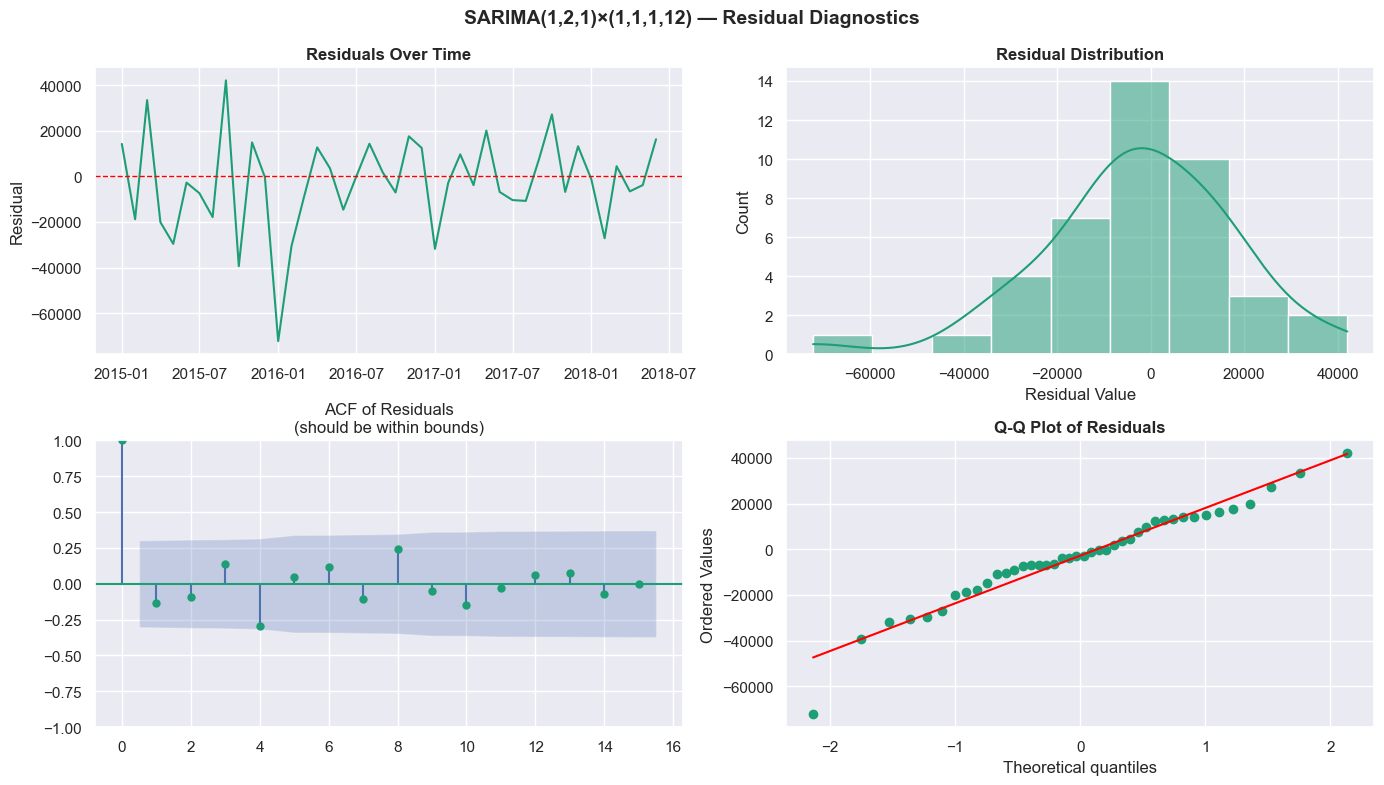

📸 Saved: sarima_residuals.png



In [57]:
# ============================================================
# 6.6 — Residual diagnostics
# ============================================================
residuals = sarima_result.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0,0].plot(residuals, color='#1D9E75', linewidth=1.5)
axes[0,0].axhline(y=0, color='red',
                  linestyle='--', linewidth=1)
axes[0,0].set_title('Residuals Over Time',
                     fontweight='bold')
axes[0,0].set_ylabel('Residual')

# Residual distribution
sns.histplot(residuals, kde=True,
             ax=axes[0,1], color='#1D9E75')
axes[0,1].set_title('Residual Distribution',
                     fontweight='bold')
axes[0,1].set_xlabel('Residual Value')

# ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.dropna(), lags=15,
         ax=axes[1,0], color='#1D9E75',
         title='ACF of Residuals\n(should be within bounds)')

# Q-Q plot
from scipy import stats
stats.probplot(residuals.dropna(), plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Residuals',
                     fontweight='bold')
axes[1,1].get_lines()[0].set(color='#1D9E75')
axes[1,1].get_lines()[1].set(color='red')

plt.suptitle(
    f'SARIMA({p},{d},{q})×({P},{D},{Q},{s}) '
    f'— Residual Diagnostics',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sarima_residuals.png', dpi=150)
plt.show()
print("📸 Saved: sarima_residuals.png\n")

In [58]:
# ============================================================
# 6.7 — Ljung-Box test on SARIMA residuals
# ============================================================
lb_test = acorr_ljungbox(
    residuals.dropna(), lags=10, return_df=True)
print("📊 Ljung-Box Test — SARIMA Residuals:")
print(f"   p-value at lag 10: "
      f"{lb_test['lb_pvalue'].iloc[-1]:.4f}")
if lb_test['lb_pvalue'].iloc[-1] > 0.05:
    print("   ✅ Residuals are white noise — great model fit\n")
else:
    print("   ⚠️  Some autocorrelation remains in residuals\n")

📊 Ljung-Box Test — SARIMA Residuals:
   p-value at lag 10: 0.2678
   ✅ Residuals are white noise — great model fit



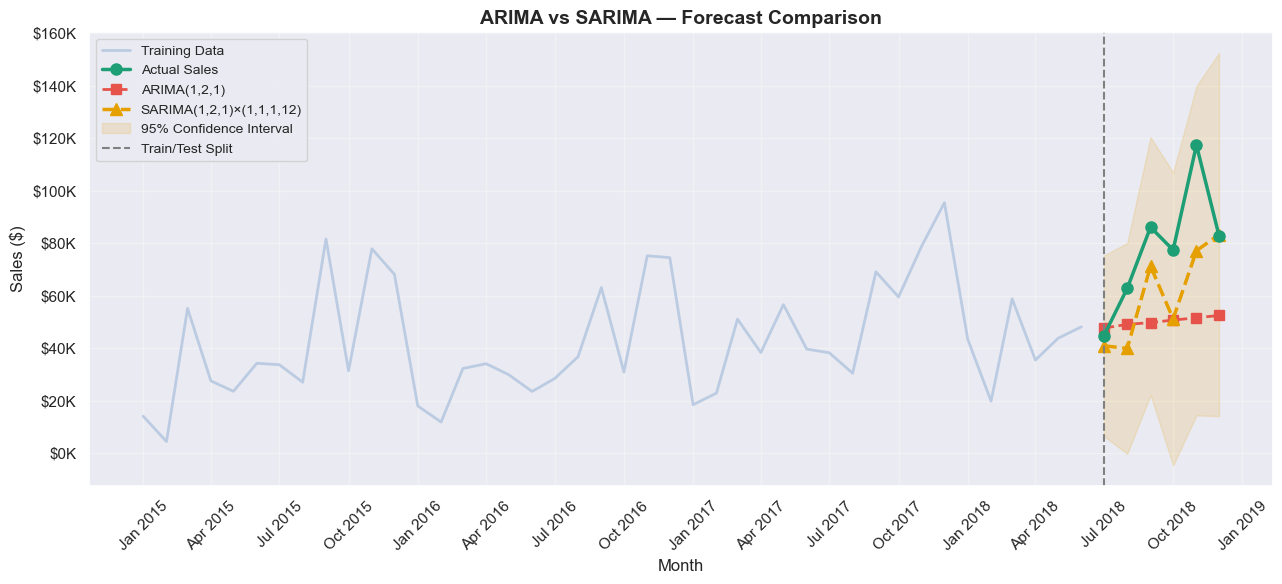

📸 Saved: arima_vs_sarima.png



In [59]:
# ============================================================
# 6.8 — Plot ARIMA vs SARIMA forecast comparison
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

# Training data
ax.plot(train.index, train.values,
        color='#B0C4DE', linewidth=2,
        label='Training Data', alpha=0.8)

# Actual test values
ax.plot(test.index, test.values,
        color='#1D9E75', linewidth=2.5,
        marker='o', markersize=8,
        label='Actual Sales', zorder=5)

# ARIMA forecast
ax.plot(arima_forecast_vals.index,
        arima_forecast_vals.values,
        color='#E5534B', linewidth=2,
        marker='s', markersize=7,
        linestyle='--',
        label=f'ARIMA({p},{d},{q})')

# SARIMA forecast
ax.plot(sarima_forecast.index, sarima_forecast.values,
        color='#E5A000', linewidth=2.5,
        marker='^', markersize=8,
        linestyle='--',
        label=f'SARIMA({p},{d},{q})×({P},{D},{Q},{s})')

# SARIMA confidence interval
ax.fill_between(
    sarima_conf_int.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    alpha=0.15, color='#E5A000',
    label='95% Confidence Interval'
)

# Train/test split line
ax.axvline(x=test.index[0], color='gray',
           linestyle='--', linewidth=1.5,
           label='Train/Test Split')

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title(
    'ARIMA vs SARIMA — Forecast Comparison',
    fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_vs_sarima.png', dpi=150)
plt.show()
print("📸 Saved: arima_vs_sarima.png\n")


In [60]:
# ============================================================
# 6.9 — Save SARIMA model & metrics
# ============================================================
joblib.dump(sarima_result, 'sarima_model.pkl')

sarima_metrics = {
    'model'   : f'SARIMA({p},{d},{q})x({P},{D},{Q},{s})',
    'MAE'     : round(mae, 2),
    'RMSE'    : round(rmse, 2),
    'MAPE'    : round(mape, 2),
    'accuracy': round(100 - mape, 2)
}

with open('sarima_metrics.json', 'w') as f:
    json.dump(sarima_metrics, f, indent=4)

print("💾 Saved: sarima_model.pkl")
print("💾 Saved: sarima_metrics.json\n")

💾 Saved: sarima_model.pkl
💾 Saved: sarima_metrics.json



In [61]:
# ============================================================
# 6.10 — Step Summary
# ============================================================
print("=" * 55)
print("✅ STEP 6 COMPLETE — SARIMA Model Built")
print("=" * 55)
print(f"  Model     : SARIMA({p},{d},{q})×({P},{D},{Q},{s})")
print(f"  MAE       : ${mae:,.2f}")
print(f"  RMSE      : ${rmse:,.2f}")
print(f"  MAPE      : {mape:.2f}%")
print(f"  Accuracy  : {100-mape:.2f}%")
print()
print(f"  vs ARIMA  : {arima_mape:.2f}% MAPE → "
      f"{mape:.2f}% MAPE")
winner = "SARIMA ✅" if mape < arima_mape else "ARIMA ⚠️"
print(f"  Winner    : {winner}")
print()
print("  📸 Plots saved:")
print("     ✔ sarima_residuals.png")
print("     ✔ arima_vs_sarima.png")
print()

✅ STEP 6 COMPLETE — SARIMA Model Built
  Model     : SARIMA(1,2,1)×(1,1,1,12)
  MAE       : $18,066.47
  RMSE      : $22,600.52
  MAPE      : 21.80%
  Accuracy  : 78.20%

  vs ARIMA  : 32.92% MAPE → 21.80% MAPE
  Winner    : SARIMA ✅

  📸 Plots saved:
     ✔ sarima_residuals.png
     ✔ arima_vs_sarima.png



In [62]:
# ============================================================
# STEP 7 — Anomaly Detection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# ============================================================
# 7.1 — Reload data & SARIMA model
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'

sarima_result = joblib.load('sarima_model.pkl')

print("✅ Data & SARIMA model reloaded\n")

✅ Data & SARIMA model reloaded



In [63]:
# ============================================================
# 7.2 — Method 1: Z-Score Anomaly Detection
# (flags points more than 2.5 std devs from mean)
# ============================================================
print("🔍 Method 1 — Z-Score Anomaly Detection\n")

rolling_mean = monthly_sales.rolling(window=3).mean()
rolling_std  = monthly_sales.rolling(window=3).std()

z_scores = (monthly_sales - rolling_mean) / rolling_std

threshold = 2.5
anomalies_zscore = monthly_sales[
    np.abs(z_scores) > threshold
].dropna()

print(f"   Threshold    : ±{threshold} std deviations")
print(f"   Anomalies found: {len(anomalies_zscore)}")
if len(anomalies_zscore) > 0:
    print("   Anomalous months:")
    for date, val in anomalies_zscore.items():
        z = z_scores[date]
        direction = "📈 Spike" if z > 0 else "📉 Drop"
        print(f"   → {date.strftime('%b %Y')}: "
              f"${val:,.0f} (z={z:.2f}) {direction}")
print()


🔍 Method 1 — Z-Score Anomaly Detection

   Threshold    : ±2.5 std deviations
   Anomalies found: 0



In [64]:
# ============================================================
# 7.3 — Method 2: IQR Anomaly Detection
# (flags points outside 1.5×IQR range)
# ============================================================
print("🔍 Method 2 — IQR Anomaly Detection\n")

Q1  = monthly_sales.quantile(0.25)
Q3  = monthly_sales.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies_iqr = monthly_sales[
    (monthly_sales < lower_bound) |
    (monthly_sales > upper_bound)
]

print(f"   Q1           : ${Q1:,.2f}")
print(f"   Q3           : ${Q3:,.2f}")
print(f"   IQR          : ${IQR:,.2f}")
print(f"   Lower bound  : ${lower_bound:,.2f}")
print(f"   Upper bound  : ${upper_bound:,.2f}")
print(f"   Anomalies found: {len(anomalies_iqr)}")
if len(anomalies_iqr) > 0:
    print("   Anomalous months:")
    for date, val in anomalies_iqr.items():
        direction = "📈 Above upper" \
            if val > upper_bound else "📉 Below lower"
        print(f"   → {date.strftime('%b %Y')}: "
              f"${val:,.0f} {direction}")
print()

🔍 Method 2 — IQR Anomaly Detection

   Q1           : $29,599.20
   Q3           : $64,391.97
   IQR          : $34,792.77
   Lower bound  : $-22,589.96
   Upper bound  : $116,581.13
   Anomalies found: 1
   Anomalous months:
   → Nov 2018: $117,394 📈 Above upper



In [67]:
# ============================================================
# 7.4 — Method 3: SARIMA Residual Anomaly Detection
# (most sophisticated — flags unusual residuals)
# ============================================================
print("Method 3 — SARIMA Residual Anomaly Detection\n")

residuals   = sarima_result.resid
resid_mean  = residuals.mean()
resid_std   = residuals.std()
resid_threshold = 2.0

# Fix — align residuals index with monthly_sales first
residuals = residuals.reindex(monthly_sales.index)

# Find anomalous dates from residuals
anomaly_mask = np.abs(residuals - resid_mean) > \
               resid_threshold * resid_std

# Apply mask to monthly_sales using aligned dates
anomalous_dates   = residuals[anomaly_mask].dropna().index
anomalies_resid   = monthly_sales[
    monthly_sales.index.isin(anomalous_dates)
]

print(f"   Residual mean : ${resid_mean:,.2f}")
print(f"   Residual std  : ${resid_std:,.2f}")
print(f"   Threshold     : ±{resid_threshold} std devs")
print(f"   Anomalies found: {len(anomalies_resid)}")
if len(anomalies_resid) > 0:
    print("   Anomalous months:")
    for date, val in anomalies_resid.items():
        resid_val = residuals[date]
        direction = "Spike" \
            if resid_val > 0 else "Drop"
        print(f"   → {date.strftime('%b %Y')}: "
              f"${val:,.0f} "
              f"(residual=${resid_val:,.0f}) {direction}")
print()

Method 3 — SARIMA Residual Anomaly Detection

   Residual mean : $-2,790.93
   Residual std  : $20,815.85
   Threshold     : ±2.0 std devs
   Anomalies found: 2
   Anomalous months:
   → Sep 2015: $81,624 (residual=$42,035) Spike
   → Jan 2016: $18,067 (residual=$-72,208) Drop



In [68]:
# ============================================================
# 7.5 — Combine all anomalies
# ============================================================
all_anomaly_dates = set(
    list(anomalies_zscore.index) +
    list(anomalies_iqr.index) +
    list(anomalies_resid.index)
)

confirmed_anomalies = monthly_sales[
    monthly_sales.index.isin(all_anomaly_dates)
]

print("=" * 55)
print("COMBINED ANOMALY SUMMARY")
print("=" * 55)
print(f"  Z-Score anomalies  : {len(anomalies_zscore)}")
print(f"  IQR anomalies      : {len(anomalies_iqr)}")
print(f"  Residual anomalies : {len(anomalies_resid)}")
print(f"  Total unique       : {len(confirmed_anomalies)}")
print()
if len(confirmed_anomalies) > 0:
    print("  All anomalous months:")
    for date, val in confirmed_anomalies.items():
        methods = []
        if date in anomalies_zscore.index:
            methods.append("Z-Score")
        if date in anomalies_iqr.index:
            methods.append("IQR")
        if date in anomalies_resid.index:
            methods.append("Residual")
        print(f"  → {date.strftime('%b %Y')}: "
              f"${val:,.0f} "
              f"[{', '.join(methods)}]")
print()

COMBINED ANOMALY SUMMARY
  Z-Score anomalies  : 0
  IQR anomalies      : 1
  Residual anomalies : 2
  Total unique       : 3

  All anomalous months:
  → Sep 2015: $81,624 [Residual]
  → Jan 2016: $18,067 [Residual]
  → Nov 2018: $117,394 [IQR]



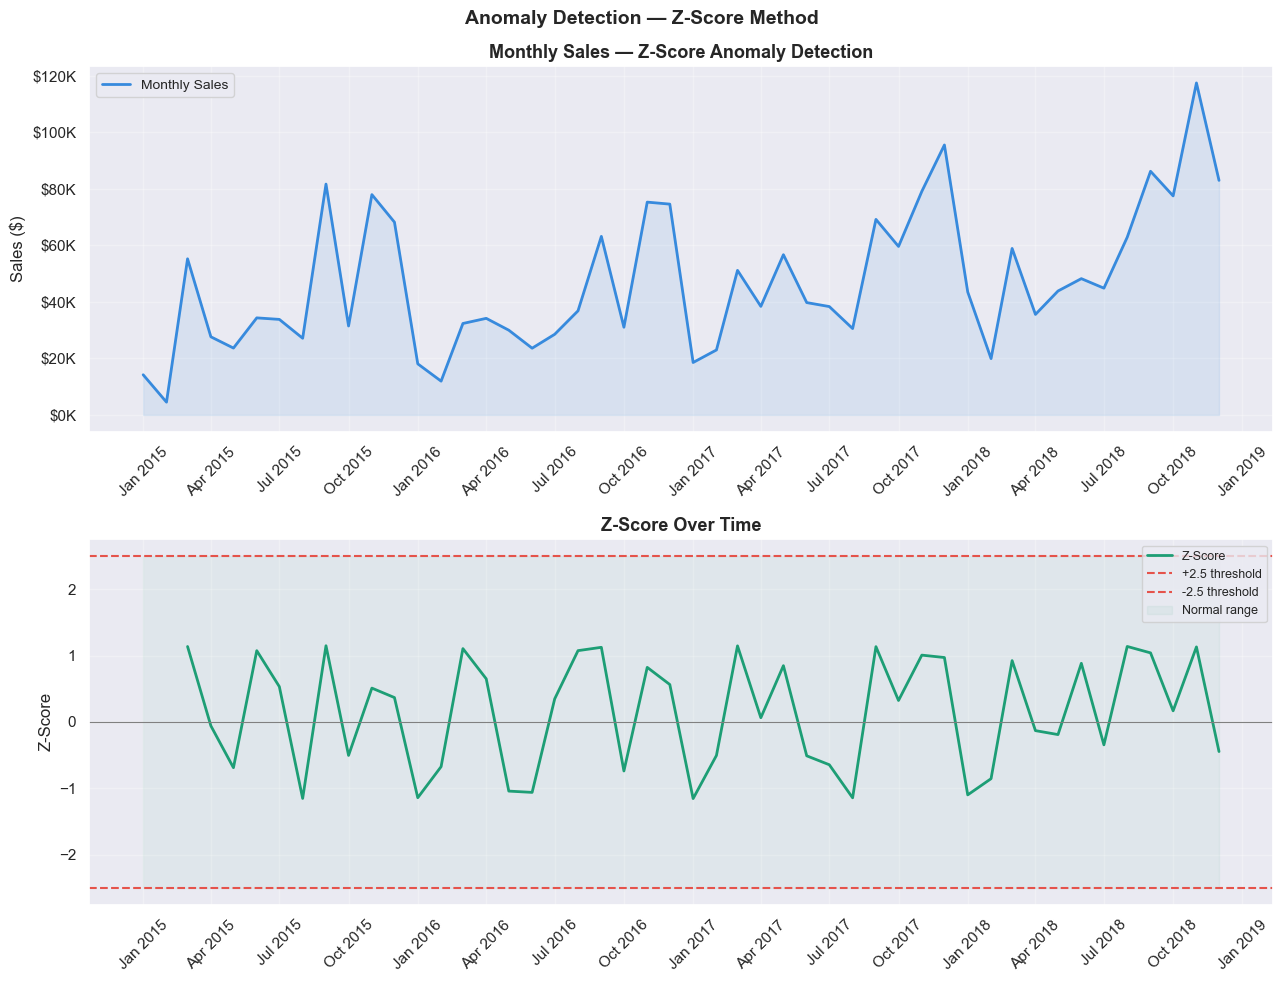

📸 Saved: anomaly_zscore.png



In [69]:
# ============================================================
# 7.6 — Plot Z-Score anomalies
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Plot 1 — Sales with anomalies highlighted
ax = axes[0]
ax.plot(monthly_sales.index, monthly_sales.values,
        color='#378ADD', linewidth=2,
        label='Monthly Sales', zorder=2)
ax.fill_between(monthly_sales.index,
                monthly_sales.values,
                alpha=0.1, color='#378ADD')

# Highlight anomalies
if len(anomalies_zscore) > 0:
    ax.scatter(anomalies_zscore.index,
               anomalies_zscore.values,
               color='#E5534B', s=120, zorder=5,
               label=f'Z-Score Anomalies '
                     f'(n={len(anomalies_zscore)})',
               marker='o')
    for date, val in anomalies_zscore.items():
        ax.annotate(
            f'{date.strftime("%b %Y")}\n${val/1000:.0f}K',
            xy=(date, val),
            xytext=(0, 15),
            textcoords='offset points',
            ha='center', fontsize=8,
            color='#E5534B', fontweight='bold'
        )

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_title('Monthly Sales — Z-Score Anomaly Detection',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2 — Z-score over time
ax2 = axes[1]
ax2.plot(z_scores.index, z_scores.values,
         color='#1D9E75', linewidth=2,
         label='Z-Score')
ax2.axhline(y=threshold, color='#E5534B',
            linestyle='--', linewidth=1.5,
            label=f'+{threshold} threshold')
ax2.axhline(y=-threshold, color='#E5534B',
            linestyle='--', linewidth=1.5,
            label=f'-{threshold} threshold')
ax2.axhline(y=0, color='gray',
            linestyle='-', linewidth=0.8)
ax2.fill_between(z_scores.index,
                 -threshold, threshold,
                 alpha=0.05, color='#1D9E75',
                 label='Normal range')

if len(anomalies_zscore) > 0:
    ax2.scatter(
        anomalies_zscore.index,
        z_scores[anomalies_zscore.index],
        color='#E5534B', s=100, zorder=5
    )

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
ax2.set_title('Z-Score Over Time',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Z-Score')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Anomaly Detection — Z-Score Method',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_zscore.png', dpi=150)
plt.show()
print("📸 Saved: anomaly_zscore.png\n")

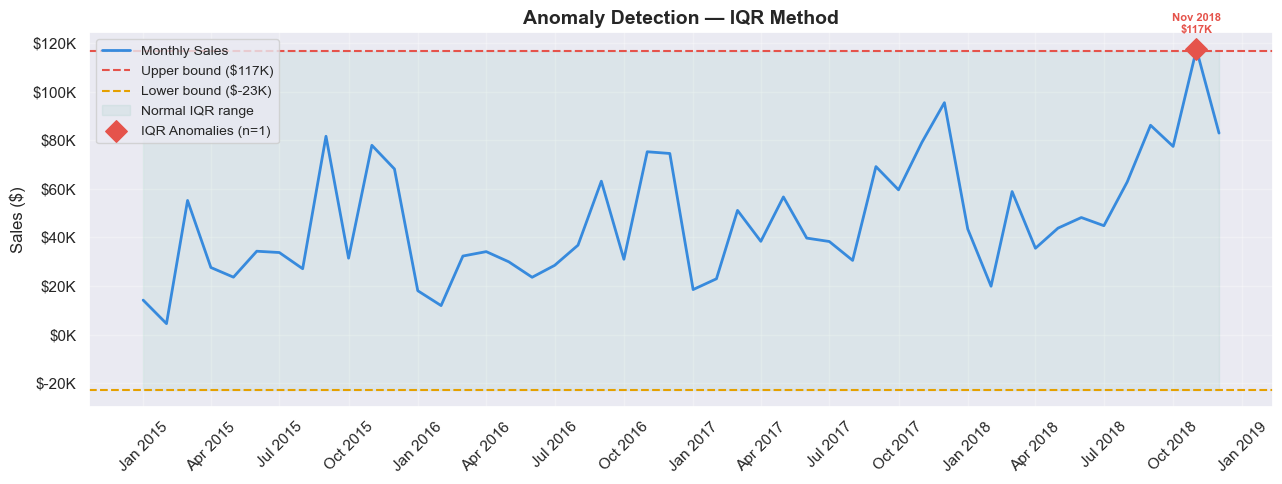

📸 Saved: anomaly_iqr.png



In [70]:
# ============================================================
# 7.7 — Plot IQR anomalies
# ============================================================
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_sales.index, monthly_sales.values,
        color='#378ADD', linewidth=2,
        label='Monthly Sales')
ax.axhline(y=upper_bound, color='#E5534B',
           linestyle='--', linewidth=1.5,
           label=f'Upper bound (${upper_bound/1000:.0f}K)')
ax.axhline(y=lower_bound, color='#E5A000',
           linestyle='--', linewidth=1.5,
           label=f'Lower bound (${lower_bound/1000:.0f}K)')
ax.fill_between(monthly_sales.index,
                lower_bound, upper_bound,
                alpha=0.07, color='#1D9E75',
                label='Normal IQR range')

if len(anomalies_iqr) > 0:
    ax.scatter(anomalies_iqr.index,
               anomalies_iqr.values,
               color='#E5534B', s=120,
               zorder=5, marker='D',
               label=f'IQR Anomalies '
                     f'(n={len(anomalies_iqr)})')
    for date, val in anomalies_iqr.items():
        ax.annotate(
            f'{date.strftime("%b %Y")}\n${val/1000:.0f}K',
            xy=(date, val),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center', fontsize=8,
            color='#E5534B', fontweight='bold'
        )

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Anomaly Detection — IQR Method',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_iqr.png', dpi=150)
plt.show()
print("📸 Saved: anomaly_iqr.png\n")

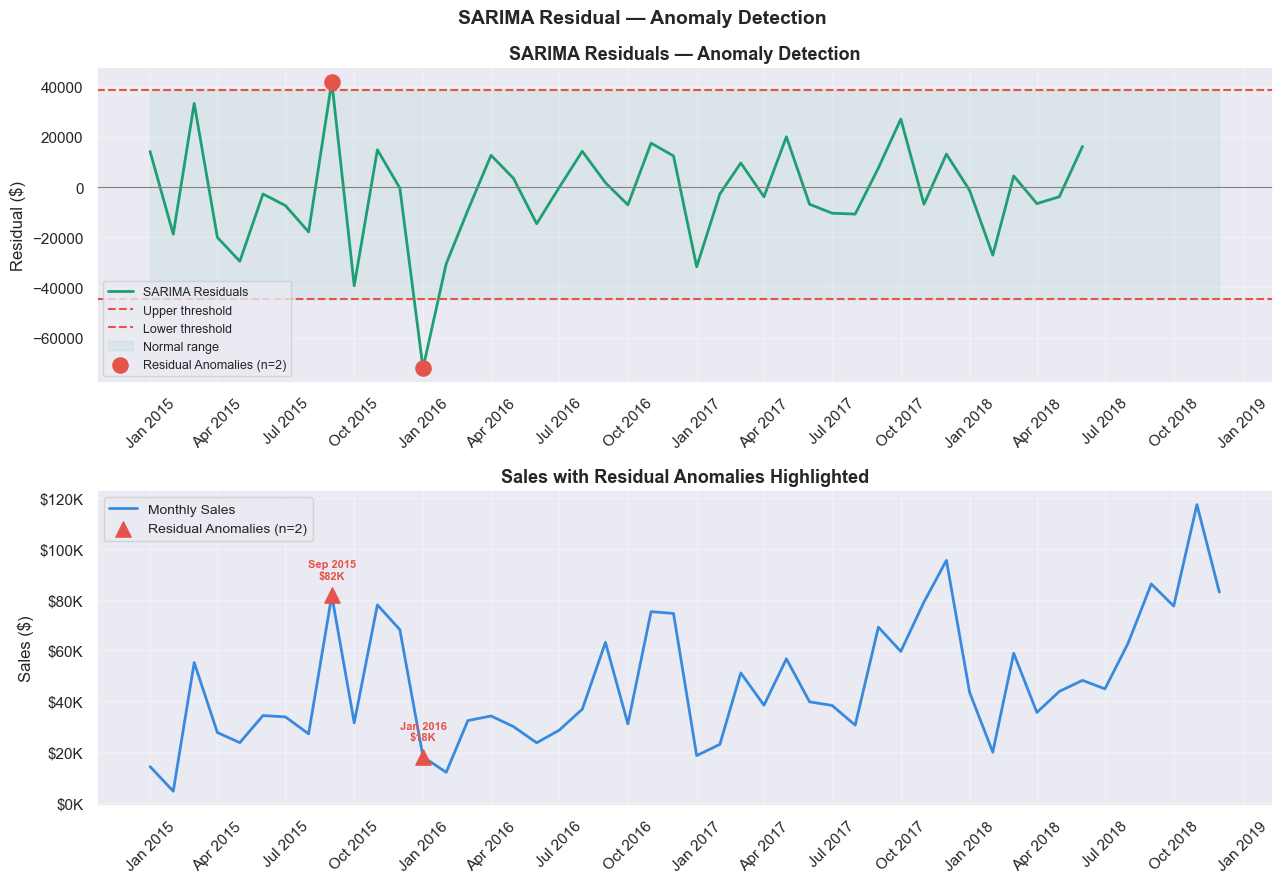

📸 Saved: anomaly_residual.png



In [71]:
# ============================================================
# 7.8 — Plot SARIMA residual anomalies
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Residuals with anomaly bands
ax = axes[0]
ax.plot(residuals.index, residuals.values,
        color='#1D9E75', linewidth=2,
        label='SARIMA Residuals')
ax.axhline(y=resid_mean + resid_threshold * resid_std,
           color='#E5534B', linestyle='--',
           linewidth=1.5, label='Upper threshold')
ax.axhline(y=resid_mean - resid_threshold * resid_std,
           color='#E5534B', linestyle='--',
           linewidth=1.5, label='Lower threshold')
ax.axhline(y=0, color='gray',
           linestyle='-', linewidth=0.8)
ax.fill_between(
    residuals.index,
    resid_mean - resid_threshold * resid_std,
    resid_mean + resid_threshold * resid_std,
    alpha=0.07, color='#1D9E75',
    label='Normal range'
)

if len(anomalies_resid) > 0:
    ax.scatter(
        anomalies_resid.index,
        residuals[anomalies_resid.index],
        color='#E5534B', s=120, zorder=5,
        label=f'Residual Anomalies '
              f'(n={len(anomalies_resid)})'
    )

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_title('SARIMA Residuals — Anomaly Detection',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Residual ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Sales with residual anomalies overlaid
ax2 = axes[1]
ax2.plot(monthly_sales.index, monthly_sales.values,
         color='#378ADD', linewidth=2,
         label='Monthly Sales')

if len(anomalies_resid) > 0:
    ax2.scatter(anomalies_resid.index,
                anomalies_resid.values,
                color='#E5534B', s=120, zorder=5,
                marker='^',
                label=f'Residual Anomalies '
                      f'(n={len(anomalies_resid)})')
    for date, val in anomalies_resid.items():
        ax2.annotate(
            f'{date.strftime("%b %Y")}\n${val/1000:.0f}K',
            xy=(date, val),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center', fontsize=8,
            color='#E5534B', fontweight='bold'
        )

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
ax2.set_title('Sales with Residual Anomalies Highlighted',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Sales ($)')
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('SARIMA Residual — Anomaly Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_residual.png', dpi=150)
plt.show()
print("📸 Saved: anomaly_residual.png\n")


In [72]:
# ============================================================
# 7.9 — Save anomaly results
# ============================================================
anomaly_report = {
    'zscore_anomalies': [
        {'date': str(d.date()), 'sales': float(v)}
        for d, v in anomalies_zscore.items()
    ],
    'iqr_anomalies': [
        {'date': str(d.date()), 'sales': float(v)}
        for d, v in anomalies_iqr.items()
    ],
    'residual_anomalies': [
        {'date': str(d.date()), 'sales': float(v)}
        for d, v in anomalies_resid.items()
    ],
    'total_unique': len(confirmed_anomalies)
}

with open('anomaly_report.json', 'w') as f:
    json.dump(anomaly_report, f, indent=4)

print("💾 Saved: anomaly_report.json\n")

💾 Saved: anomaly_report.json



In [73]:
# ============================================================
# 7.10 — Step Summary
# ============================================================
print("=" * 55)
print("✅ STEP 7 COMPLETE — Anomaly Detection Done")
print("=" * 55)
print(f"  Z-Score anomalies  : {len(anomalies_zscore)}")
print(f"  IQR anomalies      : {len(anomalies_iqr)}")
print(f"  Residual anomalies : {len(anomalies_resid)}")
print(f"  Total unique       : {len(confirmed_anomalies)}")
print()
print("  Three detection methods used:")
print("  ✔ Z-Score  — rolling mean based")
print("  ✔ IQR      — distribution based")
print("  ✔ Residual — model based (most sophisticated)")
print()
print("  📸 Plots saved:")
print("     ✔ anomaly_zscore.png")
print("     ✔ anomaly_iqr.png")
print("     ✔ anomaly_residual.png")
print()

✅ STEP 7 COMPLETE — Anomaly Detection Done
  Z-Score anomalies  : 0
  IQR anomalies      : 1
  Residual anomalies : 2
  Total unique       : 3

  Three detection methods used:
  ✔ Z-Score  — rolling mean based
  ✔ IQR      — distribution based
  ✔ Residual — model based (most sophisticated)

  📸 Plots saved:
     ✔ anomaly_zscore.png
     ✔ anomaly_iqr.png
     ✔ anomaly_residual.png



In [74]:
# ============================================================
# STEP 8 — Final Future Forecast + GitHub Preparation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")

# ============================================================
# 8.1 — Reload everything
# ============================================================
monthly_sales = pd.read_csv('monthly_sales.csv',
                             index_col=0, parse_dates=True)
monthly_sales = monthly_sales.squeeze()
monthly_sales.index.freq = 'MS'

sarima_result = joblib.load('sarima_model.pkl')

with open('arima_metrics.json',  'r') as f:
    arima_metrics  = json.load(f)
with open('sarima_metrics.json', 'r') as f:
    sarima_metrics = json.load(f)

print("✅ All models and data reloaded\n")


✅ All models and data reloaded



In [75]:

# ============================================================
# 8.2 — Refit SARIMA on FULL dataset
# (train + test — best model for future forecasting)
# ============================================================
print("🌊 Refitting SARIMA on full dataset...\n")

p, d, q = 1, 2, 1
P, D, Q, s = 1, 1, 1, 12

final_model = sarima_result.apply(monthly_sales)

print("✅ SARIMA refit on full dataset complete\n")

🌊 Refitting SARIMA on full dataset...

✅ SARIMA refit on full dataset complete



In [76]:
# ============================================================
# 8.3 — Forecast next 12 months
# ============================================================
forecast_steps = 12
forecast_obj   = final_model.get_forecast(steps=forecast_steps)
future_forecast = forecast_obj.predicted_mean
future_conf_int = forecast_obj.conf_int(alpha=0.05)

# Generate future date index
future_index = pd.date_range(
    start=monthly_sales.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq='MS'
)
future_forecast.index = future_index
future_conf_int.index = future_index

print("📅 12-Month Future Forecast:")
print(f"   {'Month':<12} {'Forecast':>12} "
      f"{'Lower 95%':>12} {'Upper 95%':>12}")
print("   " + "-" * 52)
for date, pred, lower, upper in zip(
    future_index,
    future_forecast.values,
    future_conf_int.iloc[:, 0].values,
    future_conf_int.iloc[:, 1].values
):
    print(f"   {date.strftime('%b %Y'):<12} "
          f"${pred:>10,.0f} "
          f"${lower:>10,.0f} "
          f"${upper:>10,.0f}")
print()

📅 12-Month Future Forecast:
   Month            Forecast    Lower 95%    Upper 95%
   ----------------------------------------------------
   Jan 2019     $    52,113 $    17,847 $    86,380
   Feb 2019     $    30,765 $    -9,232 $    70,761
   Mar 2019     $    66,286 $    17,502 $   115,069
   Apr 2019     $    46,826 $    -8,473 $   102,124
   May 2019     $    55,060 $    -6,995 $   117,115
   Jun 2019     $    51,360 $   -16,928 $   119,648
   Jul 2019     $    48,814 $   -25,617 $   123,245
   Aug 2019     $    55,849 $   -24,539 $   136,237
   Sep 2019     $    83,202 $    -3,054 $   169,458
   Oct 2019     $    68,763 $   -23,272 $   160,799
   Nov 2019     $   101,487 $     3,729 $   199,245
   Dec 2019     $    85,802 $   -17,632 $   189,236



In [77]:

# ============================================================
# 8.4 — Key forecast insights
# ============================================================
peak_month = future_forecast.idxmax()
low_month  = future_forecast.idxmin()
total_forecast = future_forecast.sum()

print("📊 Forecast Insights:")
print(f"   Peak month     : {peak_month.strftime('%B %Y')} "
      f"(${future_forecast.max():,.0f})")
print(f"   Lowest month   : {low_month.strftime('%B %Y')} "
      f"(${future_forecast.min():,.0f})")
print(f"   Total forecast : ${total_forecast:,.0f}")
print(f"   Avg per month  : ${future_forecast.mean():,.0f}\n")

📊 Forecast Insights:
   Peak month     : November 2019 ($101,487)
   Lowest month   : February 2019 ($30,765)
   Total forecast : $746,327
   Avg per month  : $62,194



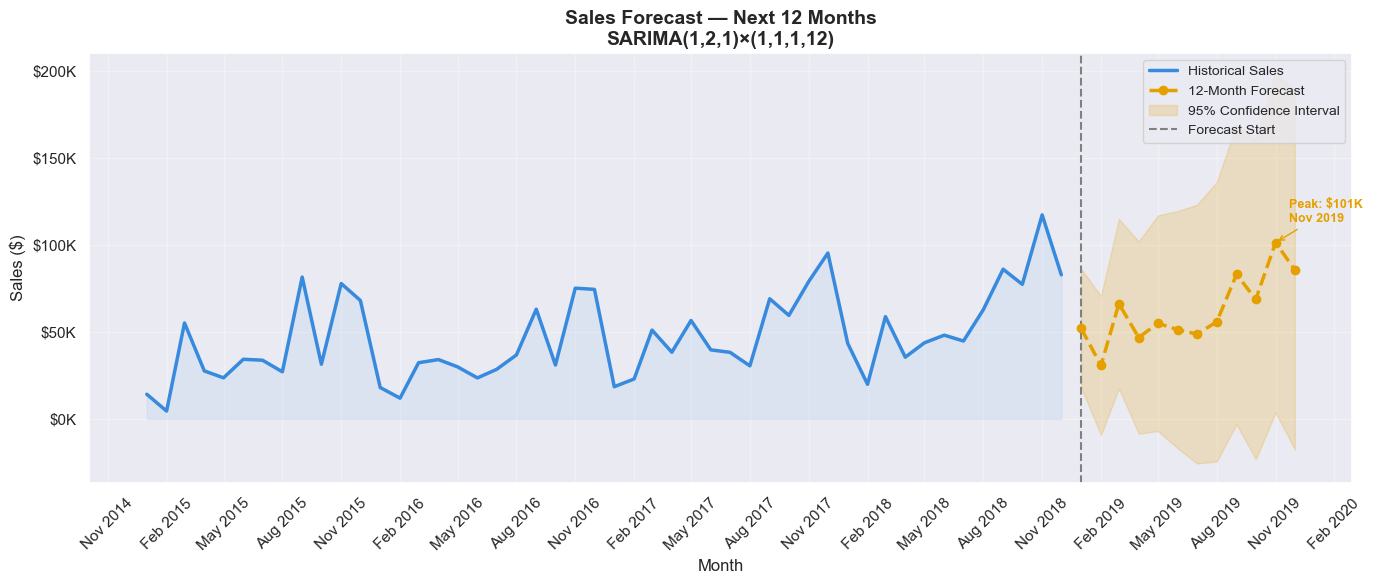

📸 Saved: future_forecast.png



In [78]:
# ============================================================
# 8.5 — Plot full history + future forecast
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Historical sales
ax.plot(monthly_sales.index, monthly_sales.values,
        color='#378ADD', linewidth=2.5,
        label='Historical Sales', zorder=3)
ax.fill_between(monthly_sales.index,
                monthly_sales.values,
                alpha=0.08, color='#378ADD')

# Future forecast
ax.plot(future_forecast.index, future_forecast.values,
        color='#E5A000', linewidth=2.5,
        marker='o', markersize=6,
        linestyle='--',
        label='12-Month Forecast', zorder=4)

# Confidence interval
ax.fill_between(
    future_conf_int.index,
    future_conf_int.iloc[:, 0],
    future_conf_int.iloc[:, 1],
    alpha=0.2, color='#E5A000',
    label='95% Confidence Interval'
)

# Divider line
ax.axvline(x=future_forecast.index[0],
           color='gray', linestyle='--',
           linewidth=1.5, label='Forecast Start')

# Annotate peak
ax.annotate(
    f"Peak: ${future_forecast.max()/1000:.0f}K\n"
    f"{peak_month.strftime('%b %Y')}",
    xy=(peak_month, future_forecast.max()),
    xytext=(10, 15), textcoords='offset points',
    fontsize=9, color='#E5A000', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E5A000')
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title(
    'Sales Forecast — Next 12 Months\n'
    f'SARIMA({p},{d},{q})×({P},{D},{Q},{s})',
    fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()
print("📸 Saved: future_forecast.png\n")

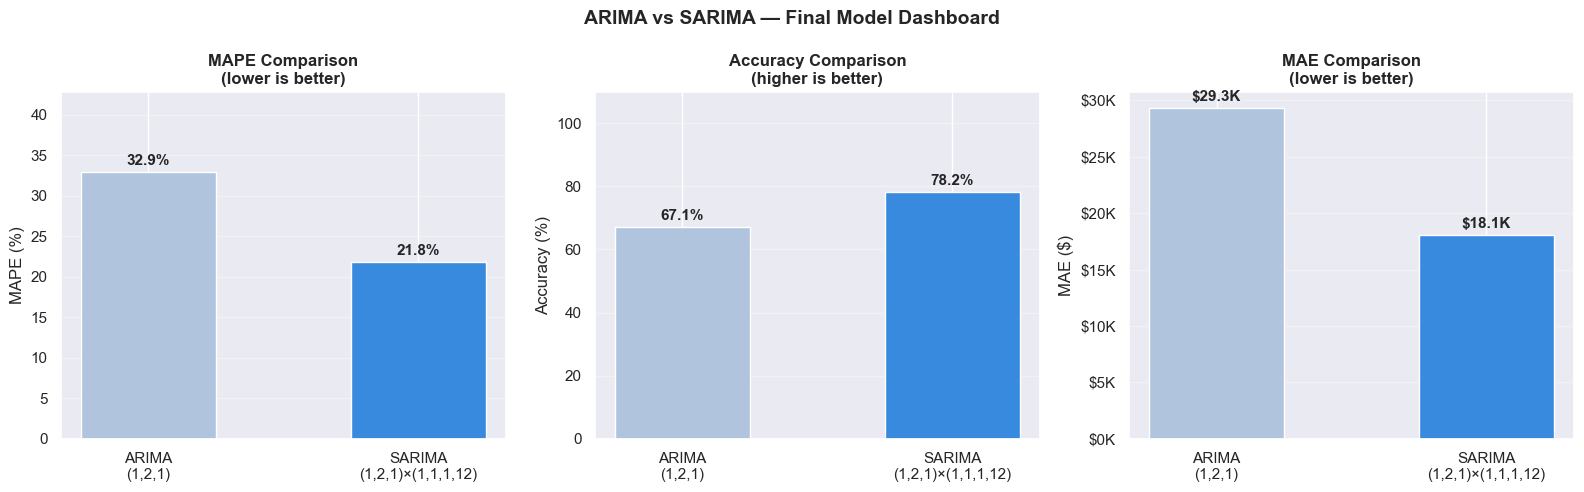

📸 Saved: final_comparison_dashboard.png



In [79]:
# ============================================================
# 8.6 — Final model comparison dashboard
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — MAPE comparison
models  = ['ARIMA\n(1,2,1)', 'SARIMA\n(1,2,1)×(1,1,1,12)']
mapes   = [arima_metrics['MAPE'], sarima_metrics['MAPE']]
colors  = ['#B0C4DE', '#378ADD']

bars = axes[0].bar(models, mapes, color=colors,
                   width=0.5, edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f%%',
                  fontsize=11, fontweight='bold', padding=3)
axes[0].set_title('MAPE Comparison\n(lower is better)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_ylim(0, max(mapes) * 1.3)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — Accuracy comparison
accuracies = [arima_metrics['accuracy'],
              sarima_metrics['accuracy']]
bars2 = axes[1].bar(models, accuracies,
                    color=colors, width=0.5,
                    edgecolor='white')
axes[1].bar_label(bars2, fmt='%.1f%%',
                  fontsize=11, fontweight='bold', padding=3)
axes[1].set_title('Accuracy Comparison\n(higher is better)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3 — MAE comparison
maes  = [arima_metrics['MAE'], sarima_metrics['MAE']]
bars3 = axes[2].bar(models, maes,
                    color=colors, width=0.5,
                    edgecolor='white')
axes[2].bar_label(bars3,
                  labels=[f'${v/1000:.1f}K' for v in maes],
                  fontsize=11, fontweight='bold', padding=3)
axes[2].set_title('MAE Comparison\n(lower is better)',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAE ($)')
axes[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('ARIMA vs SARIMA — Final Model Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison_dashboard.png', dpi=150)
plt.show()
print("📸 Saved: final_comparison_dashboard.png\n")

In [80]:
# ============================================================
# 8.7 — Save forecast to CSV
# ============================================================
forecast_df = pd.DataFrame({
    'Month'        : future_index.strftime('%B %Y'),
    'Forecast'     : future_forecast.values.round(2),
    'Lower_95'     : future_conf_int.iloc[:, 0].values.round(2),
    'Upper_95'     : future_conf_int.iloc[:, 1].values.round(2)
})
forecast_df.to_csv('future_forecast.csv', index=False)
print("💾 Saved: future_forecast.csv\n")

💾 Saved: future_forecast.csv

